In [1]:
import pandas as pd
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')
from copy import deepcopy,copy
from datetime import datetime
import pickle
import os
import scipy
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "rguimera-machine-scientist-constrained/machinescientist_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms_ode = SourceFileLoader("ms_ode", path).load_module()


folder_name = 'Train_test_data_lin_term_com2025_03_11-11_21_44'

with open(f'./{folder_name}/x.pkl', 'rb') as file:
    # A new file will be created
    x = pickle.load(file)
    
with open(f'./{folder_name}/y.pkl', 'rb') as file:
    # A new file will be created
    y = pickle.load(file)
"""
with open(f'./{folder_name}/x_test.pkl', 'rb') as file:
    # A new file will be created
    x=pickle.load(file)
    
with open(f'./{folder_name}/y_test.pkl', 'rb') as file:
    # A new file will be created
    y=pickle.load(file)
"""

def RK_BMS(model,y0,h,steps,col):
    res=[y0]
    for i in range(steps-1):
        k1 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        k2 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k1/2.]})})[col].to_numpy()[0]
        k3 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k2/2.]})})[col].to_numpy()[0]
        k4 = h*model.predict({col:pd.DataFrame(data={'B':[res[-1]+k3]})})[col].to_numpy()[0]

        # Calculate new x and y
        res.append(res[-1] + 1./6*(k1+2*k2+2*k3+k4))
        """x = x + dx
        f=model.predict({col:pd.DataFrame(data={'B':[res[-1]]})})[col].to_numpy()[0]
        res.append(res[-1]+h*f)"""
    return res

# Uncomment to fit Gmpertz growth

#string = '((_a1_ * ((B + _a0_) * (log((_a2_ / (B + _a0_)))))))' #Gompertz
string = '((_a0_ * (B + _a2_)) + (_a1_ * ((B + _a2_) * log((B + _a2_)))))' #Gompertz
bms_fulldata = ms_ode.from_string_model(x,y,string,1,8,['B'],silence=True)
print(bms_fulldata.E)

_a1_
Fit from fit 0.3007712514186202 -8.33906498298731e-08
Fit from par 0.3007712514186217 2.6829649613091533e-12
Fit from fit 0.04154518003528029 1.0349662682429539e-08
Fit from par 0.041545180035279655 1.0340924894158832e-08
Fit from fit 0.792642503435218 2.4118714342380443e-07
Fit from par 0.7926425034352275 -7.79515341164938e-12
Fit from fit 0.11057043656483206 5.5344617777564054e-14
Fit from par 0.11057043656483347 6.0253730893577995e-09
Fit from fit 0.38261077528074855 9.55188521611916e-08
Fit from par 0.38261077528075194 6.287748099964574e-12
Fit from fit 0.22453328747213755 8.324762323930202e-09
Fit from par 0.2245332874721352 4.456601754299072e-12
Fit from fit 0.6459504565035689 4.012280618859165e-09
Fit from par 0.6459504565035621 1.3366641127277035e-11
Fit from fit 0.22757715388520458 1.3415786981330058e-08
Fit from par 0.22757715388520441 6.698120447179434e-09
Fit from fit 0.24176991837710438 1.2002180171943877e-07
Fit from par 0.24176991837710202 -1.5013048804135565e-08
Fi

#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log(B)))) # # # # #


Fit from par 0.029281488129801737 -0.006357709904564274
Fit from fit 0.01373989840986465 -0.0026641632926923675
Fit from par nan nan
Fit from fit 0.02814019261253702 -0.006669864366917966
Fit from par 0.028140192606685287 -0.006669844690512794
Fit from fit 0.04519156072944699 0.004845085582285857
Fit from par nan nan
Fit from fit nan nan
Fit from par 0.0060765243143115506 -0.0007084136044693684
E5
Get SSE, fit 2 error(x0) No active exception to reraise
[0.112469, -0.17842207543098237, -0.11396821246922571, -0.40848959801248563]
[0.112469, 0.5430136036252761, -0.10734225098026846, -0.8596041256314275]
Traceback (most recent call last):
  File "/export/home/shared/Projects/IntegralBMS/Integral_BMS_Governing_Equations/Bacteria/rguimera-machine-scientist-constrained/mcmc_ode.py", line 835, in get_sse
    raise
RuntimeError: No active exception to reraise

No offset fit successful
results ([0.112469, -0.17842207543098237, -0.11396821246922571, -0.40848959801248563], [[0.112469, -0.178422075

#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log(B)))) # # # # #


Fit from fit 0.06134925482968747 0.004637108907529122
Fit from par 0.0613492548070788 0.004634545912893168
Fit from fit 0.034342777603585214 -0.006787733490614817
Fit from par 0.03434277760844806 -0.006787745740649026
Fit from fit 0.028133115081777488 -0.009556147423682965
Fit from par nan nan
Fit from fit 0.015945862678593128 -0.00034685902425821147
Fit from par nan nan
Fit from fit 0.007729960974414336 -0.00016991873163535454
Fit from par 0.007729960973730077 -0.0001698470740210123
Fit from fit 0.021875823692181447 -0.004833919018614186
Fit from par nan nan
Fit from fit 0.016313210203036662 -0.00024032596644121829
Fit from par 0.016313210196117214 -0.00024012243265734978
Fit from fit 0.00573346352934101 -0.00283226260418154
Fit from par nan nan
Fit from fit nan nan
Fit from par nan nan
R.S.6 Myo-Inositol, 0.3%_6
Get SSE, fit 2 error(x0) No active exception to reraise
[0.137858, -0.3880205382565685, -0.5621001038186415, -0.19826502306829447]
[0.137858, 0.1405373300477723, -0.550939997

...

Fit from fit nan nan
Fit from par nan nan
R.S.6 D-Salicin, 0.3%_6
Get SSE, fit 2 error(x0) No active exception to reraise
[0.173671, -0.23249443011835788, -0.5405514980120605, -0.041137960684122434]
[0.173671, -0.23249443011835788, -0.5405514980120605, -0.041137960684122434]
Traceback (most recent call last):
  File "/export/home/shared/Projects/IntegralBMS/Integral_BMS_Governing_Equations/Bacteria/rguimera-machine-scientist-constrained/mcmc_ode.py", line 835, in get_sse
    raise
RuntimeError: No active exception to reraise

No offset fit successful
results ([0.173671, -0.23249443011835788, -0.5405514980120605, -0.041137960684122434], [[0.173671, -0.23249443011835788, -0.5405514980120605, -0.041137960684122434], [0.173671, -0.23249443011835788, -0.5405514980120605, -0.041137960684122434]])
curvefit (array([-0.23249443, -0.5405515 , -0.04113796]), array([[inf, inf, inf],
       [inf, inf, inf],
       [inf, inf, inf]]))
curvefit deriv (array([-0.23249443, -0.5405515 , -0.04113796]), ar

#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #


No offset fit successful
results ([0.1154, -0.16229886489703446, -0.10354012936404837, -0.17612371098069324], [[0.1154, -0.16229886489703446, -0.10354012936404837, -0.17612371098069324], [0.1154, -0.16229886489703446, -0.10354012936404837, -0.17612371098069324]])
curvefit (array([-0.16229886, -0.10354013, -0.17612371]), array([[3.89835447e-05, 1.12712426e-05, 2.99631698e-05],
       [1.12712426e-05, 3.78121907e-06, 8.79433507e-06],
       [2.99631698e-05, 8.79433507e-06, 2.32392449e-05]]))
curvefit deriv (array([-0.17733082, -0.10822043, -0.1881644 ]), array([[1.72877154e-04, 4.03565126e-05, 1.35747697e-04],
       [4.03565126e-05, 2.46713647e-05, 2.67224700e-05],
       [1.35747697e-04, 2.67224700e-05, 1.11936886e-04]]))
Fit from fit nan nan
Fit from par nan nan
N- acetyl D Glucosamine_10
Get SSE, fit 2 error(x0) No active exception to reraise
[0.1132, -0.3649395393189108, -0.13800069684591473, -1.5522440375733992]
[0.1132, -0.3649395393189108, -0.13800069684591473, -1.552244037573399

#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #
#Cannot_fit:((_a0_*(B+_a2_))+(_a1_*((B+_a2_)*log((B+_a2_))))) # # # # #


Fit from fit 0.007021534351799981 2.4705823636894664e-09
Fit from par 0.0070215343517977995 1.7513766964460942e-08
Fit from fit nan nan
Fit from par 0.00421874848174386 -7.677555105556344e-09
R.S.18 Cytosine_18
Get SSE, fit 2 error(x0) No active exception to reraise
[0.11234714684407338, -0.07714473955293784, -0.11245494244859121, -0.13553375576723353]
[0.128531, -0.05282695411055225, -0.07135175173333445, -0.11457303928152936]
Traceback (most recent call last):
  File "/export/home/shared/Projects/IntegralBMS/Integral_BMS_Governing_Equations/Bacteria/rguimera-machine-scientist-constrained/mcmc_ode.py", line 835, in get_sse
    raise
RuntimeError: No active exception to reraise

No offset fit successful
results ([0.128531, -0.06730057802544555, -0.1067506556270986, -0.12474650960374152], [[0.128531, -0.06730057802544555, -0.1067506556270986, -0.12474650960374152], [0.128531, -0.06730057802544555, -0.1067506556270986, -0.12474650960374152]])
curvefit (array([-0.06730058, -0.10675066, -0

In [2]:
def loss_ode(param):
    model=[]
    for value in x[col].B.to_numpy():
        model.append((value+param[2])*param[0]+param[1]*(value+param[2])*np.log(value+param[2]))
    return np.sum(np.square(np.subtract(model,x[col].dx.to_numpy())))
def ode0(y,t,a,b,c):
    return (y+c)*a + b * (y+c)* np.log(y+c)
def fit_initial_value(x0):
    h=x[col].t[1]-x[col].t[0]
    #print('initial BMS fit',col)
    int0 = RK_BMS(bms_fulldata_new,x0[0],h,len(y[col]),col)
    return np.sum(np.square(np.subtract(int0,x[col].B.to_numpy())))

oo
-0.20056412982440036 -0.6488769010587522 -0.40600629924943765
inverted parabola?


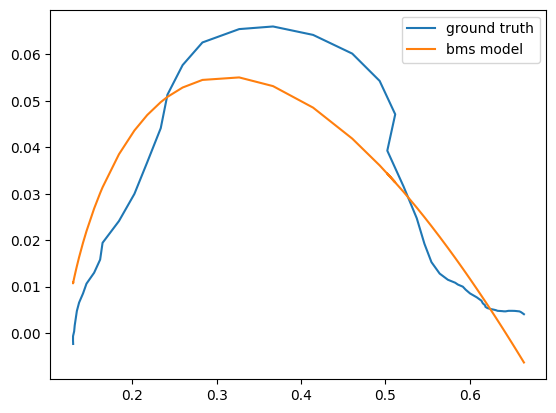

0.124266
(-9.999, 0.5)
optimized x0 [0.130151] 0.130151
final fit


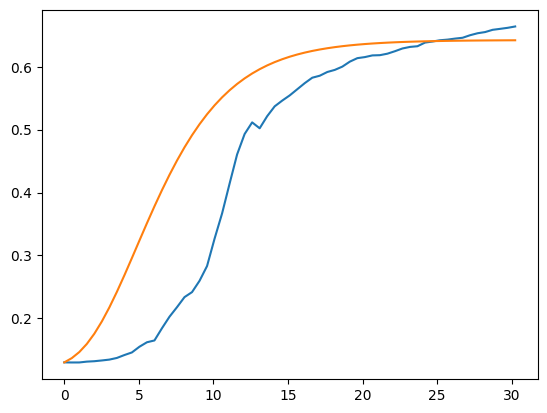

-0.0587576766972805 -0.5624419773054321 -0.10993712084249785
inverted parabola?


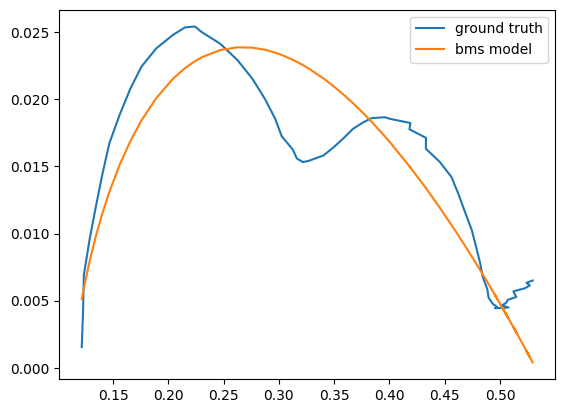

0.1133
(-9.999, 0.5)
optimized x0 [0.121746] 0.121746
final fit


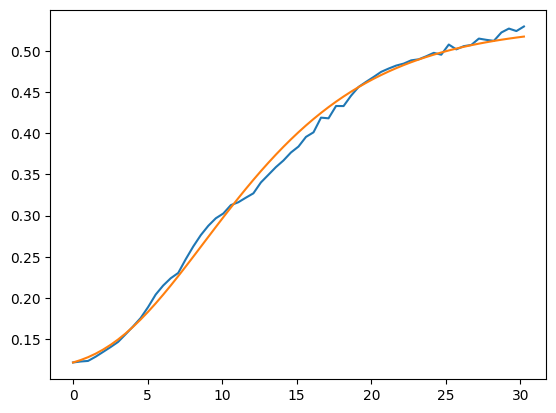

-0.4519634025170553 -0.6653505345986551 -0.5986775195073515
inverted parabola?


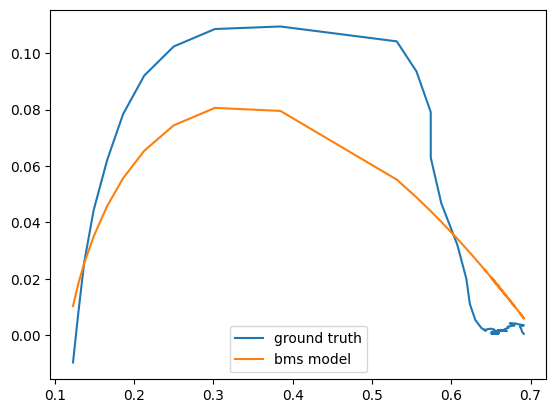

0.11688663565679827
(-9.999, 0.5)
optimized x0 [0.12576993] 0.122811
final fit


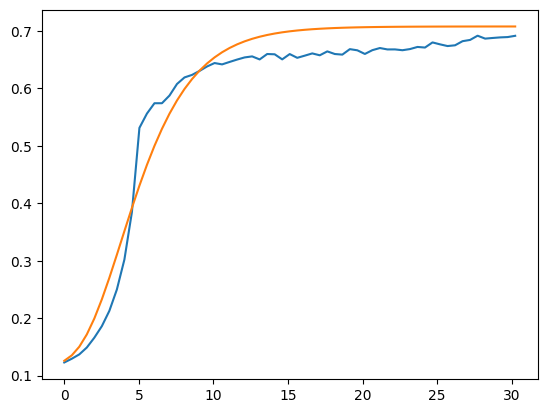

-0.08759219136199413 -0.5527400988156507 -0.1554467769449486
inverted parabola?


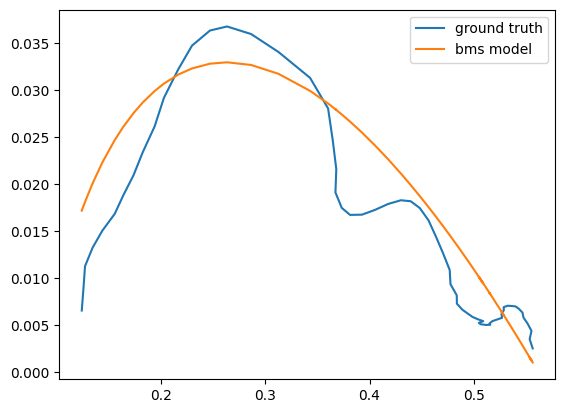

0.141528
(-9.999, 0.5)
optimized x0 [0.124365] 0.124365
final fit


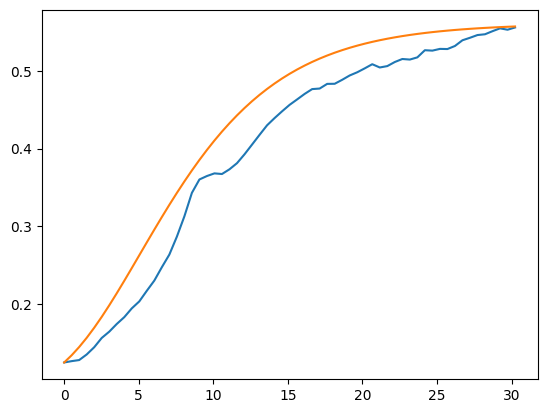

-0.3126179377845319 -0.12469710198316698 -0.21381941743867722
inverted parabola?


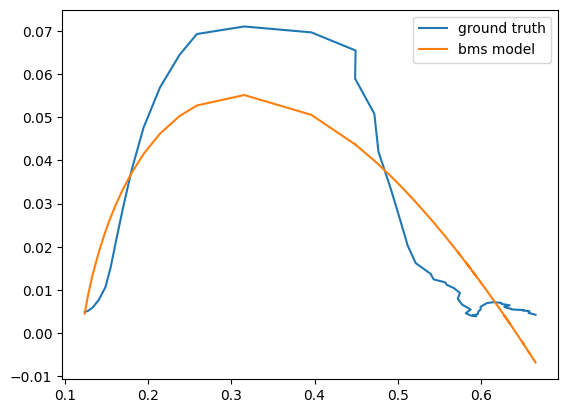

0.124266
(-9.999, 0.5)
optimized x0 [0.12515316] 0.12515315928974796
final fit


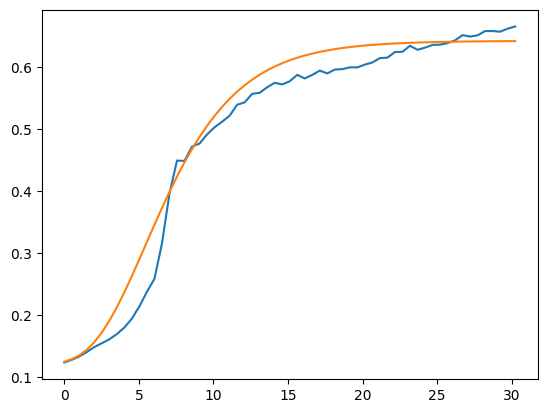

-0.06059760384145679 -0.5249097413305972 -0.20646671634126093
inverted parabola?


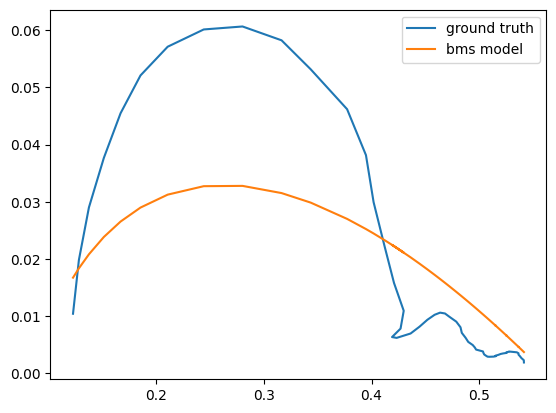

0.141528
(-9.999, 0.5)
optimized x0 [0.15025183] 0.12307
final fit


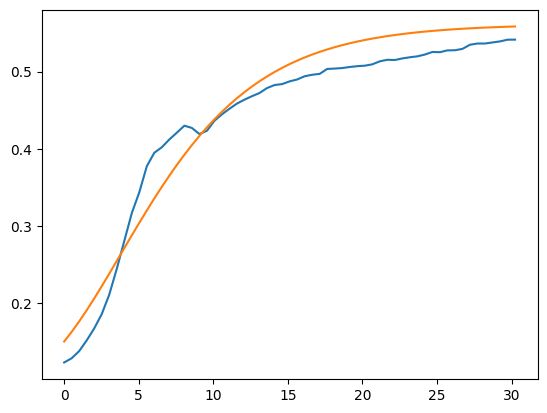

-0.37530301537686855 -0.11684857780713509 -0.19744191716676207
inverted parabola?


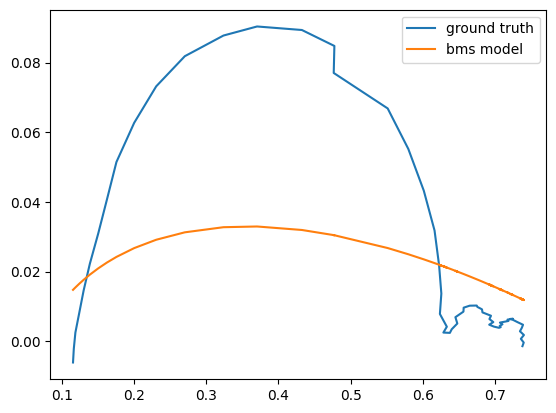

0.11297221342708645
(-9.999, 0.5)
optimized x0 [0.17572623] 0.11688663565679827
final fit


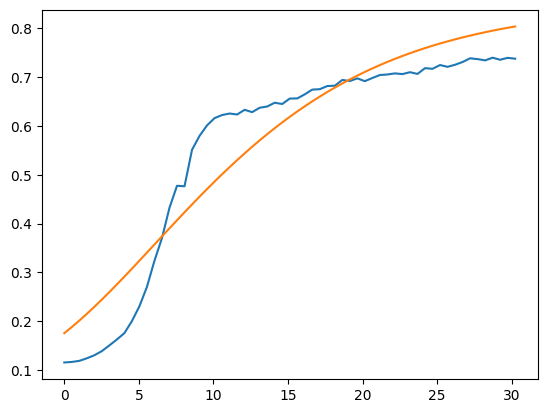

-1.2198808855990222 -0.1628836355495814 -0.15793773755846607
inverted parabola?


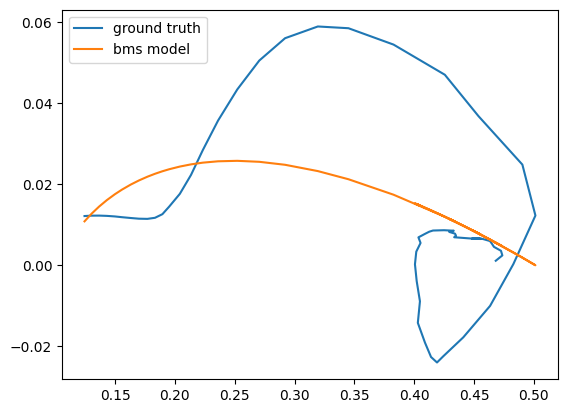

0.1154
(-9.999, 0.5)
optimized x0 [0.124449] 0.124449
final fit


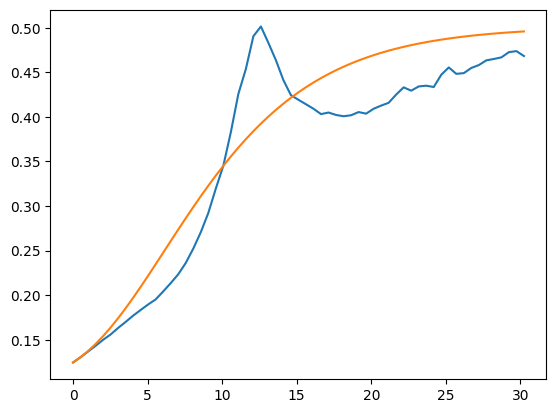

-0.40848959801248563 -0.11396821246922571 -0.17842207543098237
inverted parabola?


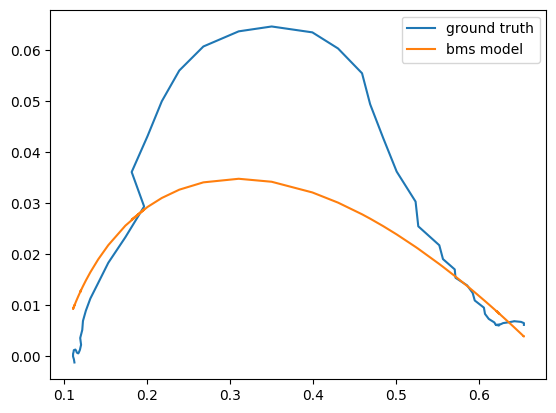

0.12657879516559173
(-9.999, 0.5)
optimized x0 [0.112469] 0.112469
final fit


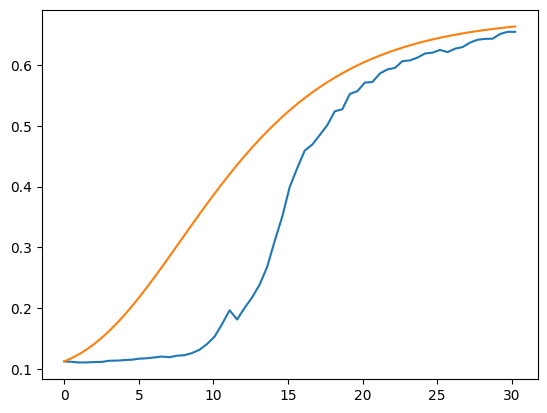

-0.2874982451685087 -0.12076805499231837 -0.18711535197051407
inverted parabola?


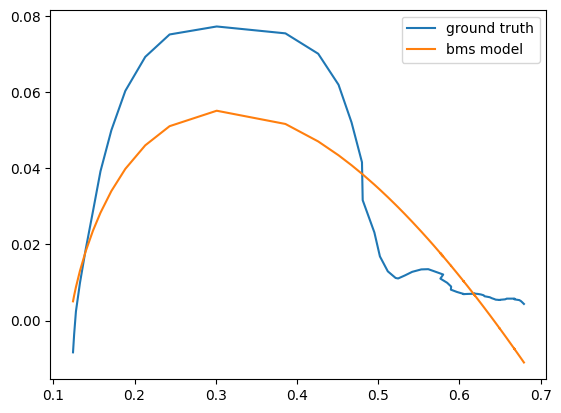

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.124266] 0.124266
final fit


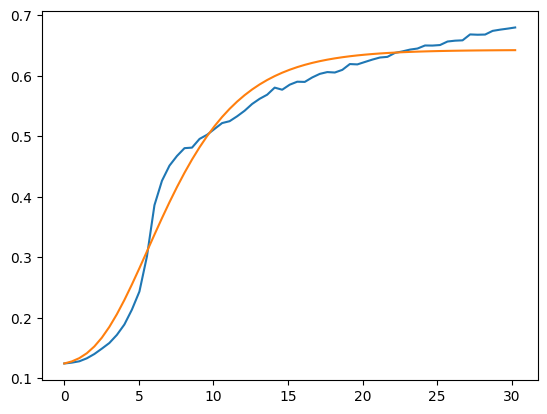

-0.25426565152883174 -0.1238373405279901 -0.11948986965199196
inverted parabola?


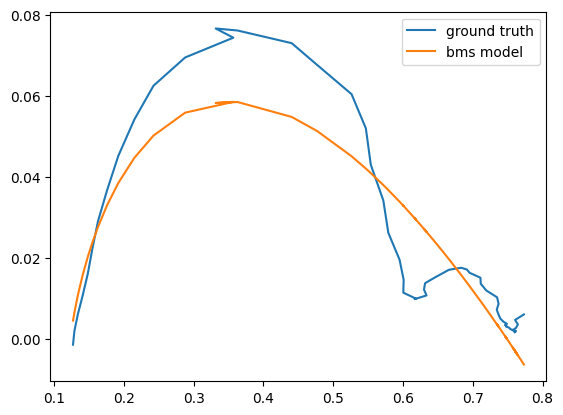

0.127212
(-9.999, 0.5)
optimized x0 [0.127212] 0.127212
final fit


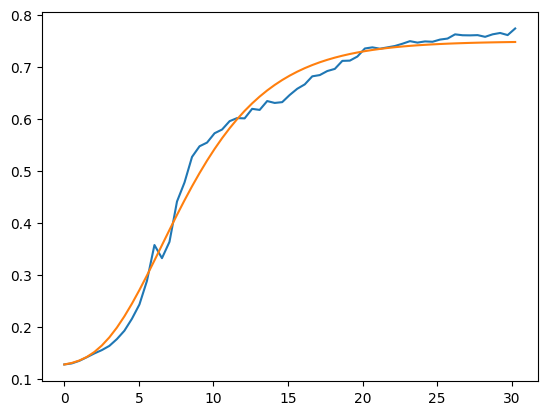

0.03869953184566437 -0.6406473013877152 -0.05516449004698629
inverted parabola?


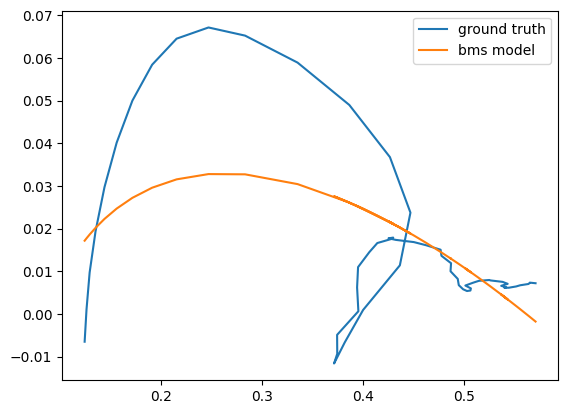

0.141528
(-9.999, 0.5)
optimized x0 [0.12448] 0.12448
final fit


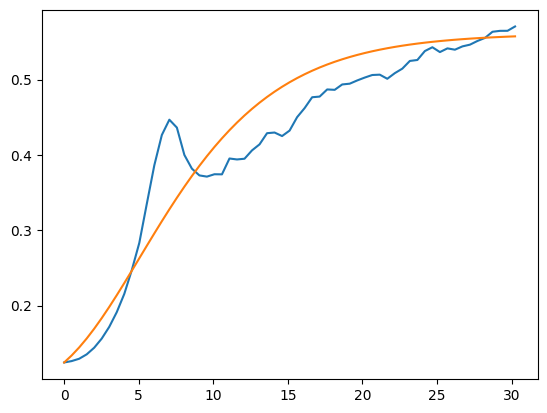

-0.29527482409099 -0.10858597909794755 -0.23971643196316217
inverted parabola?


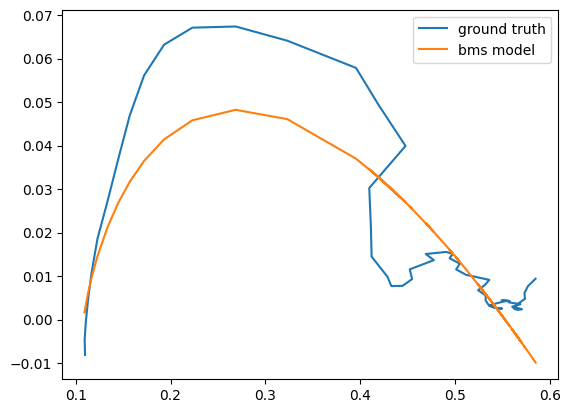

0.109895
(-9.999, 0.5)
optimized x0 [0.109895] 0.109895
final fit


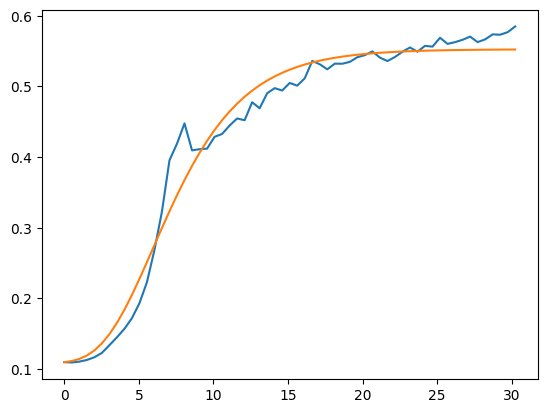

-0.11592685410181777 -0.6203836755227 -0.23521287688274736
inverted parabola?


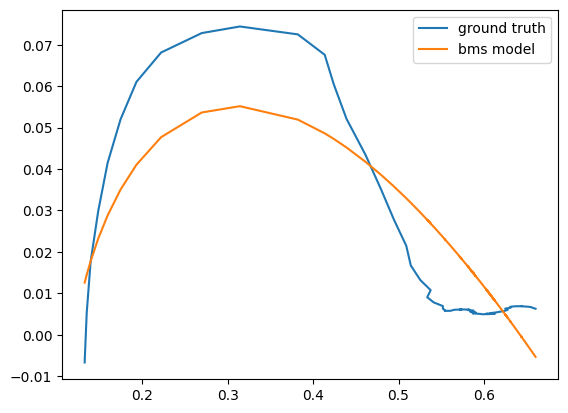

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.132246] 0.132246
final fit


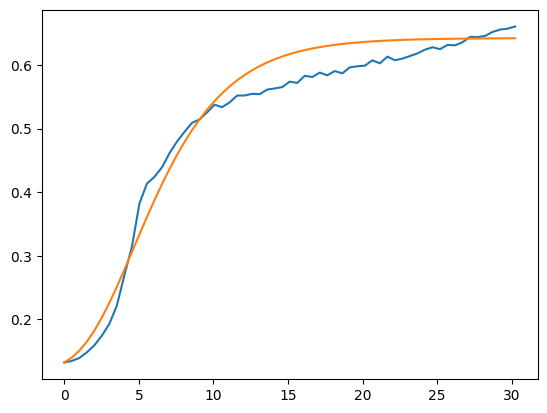

-0.18649269793862927 -0.6419913178771883 -0.4163479139661697
inverted parabola?


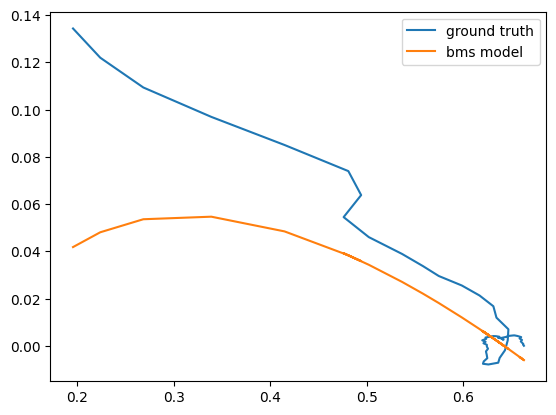

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.29235156] 0.19573
final fit


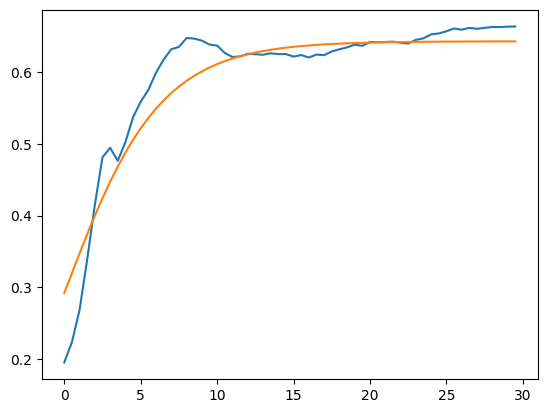

-0.041137960684122434 -0.5405514980120605 -0.23249443011835788
inverted parabola?


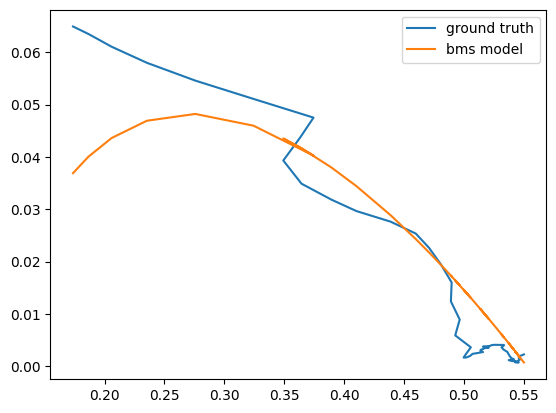

0.109895
(-9.999, 0.5)
optimized x0 [0.18068329] 0.173671
final fit


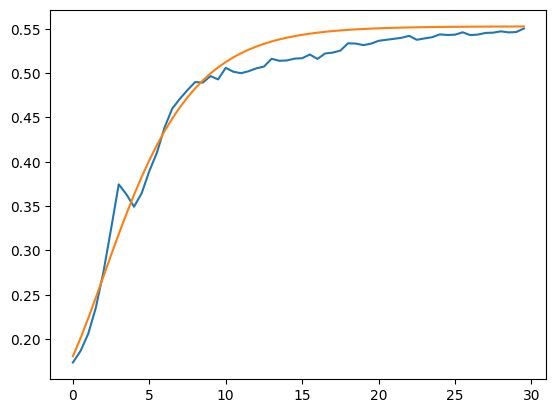

-0.11107413727556932 -0.714415876580473 -0.1641792469242351
inverted parabola?


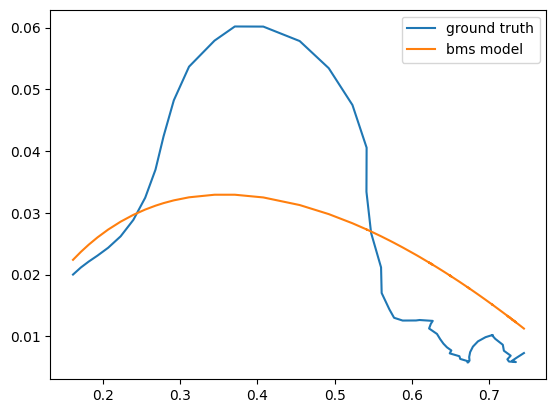

0.17572623471363114
(-9.999, 0.5)
optimized x0 [0.17753582] 0.161275
final fit


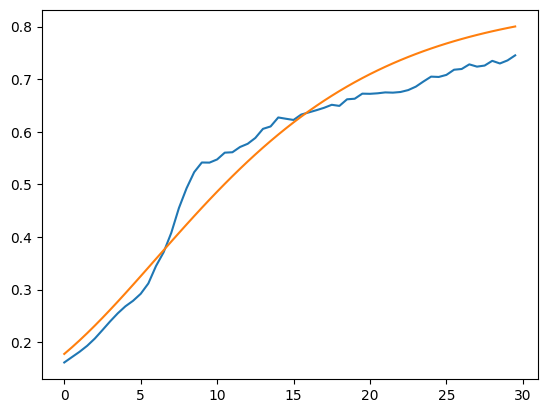

-0.18986369258096966 -0.08980791819392511 -0.1426845731504452
inverted parabola?


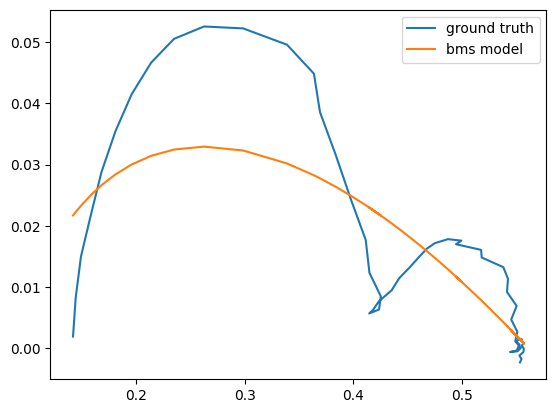

0.141528
(-9.999, 0.5)
optimized x0 [0.141528] 0.141528
final fit


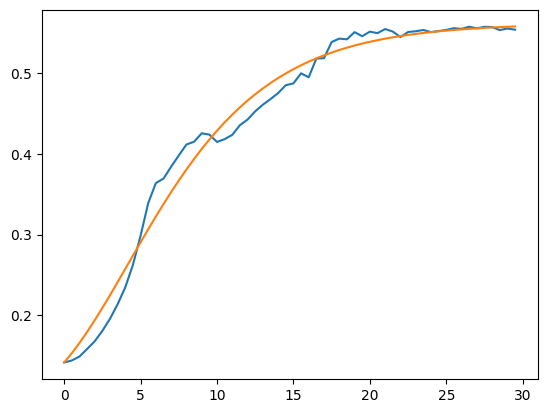

-0.21108021063414212 -0.6066100249652003 -0.294779701824166
inverted parabola?


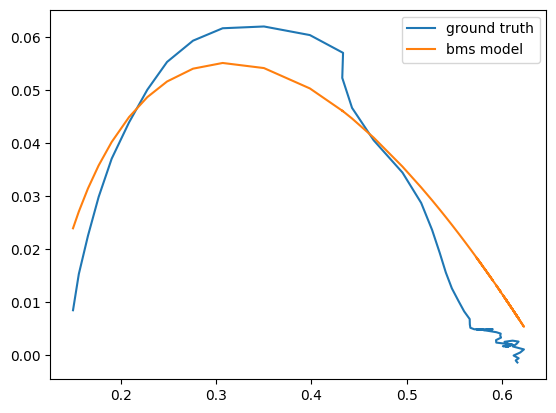

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.149546] 0.149546
final fit


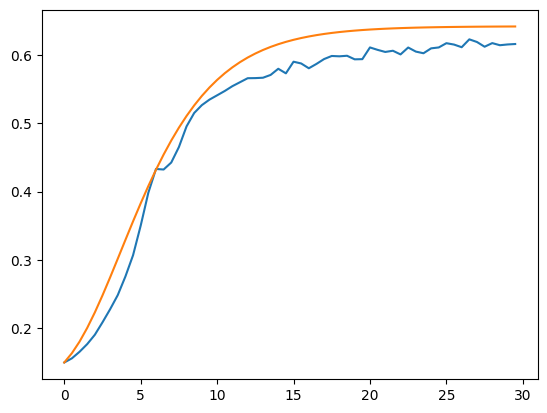

-0.19826502306829447 -0.5621001038186415 -0.3880205382565685
inverted parabola?


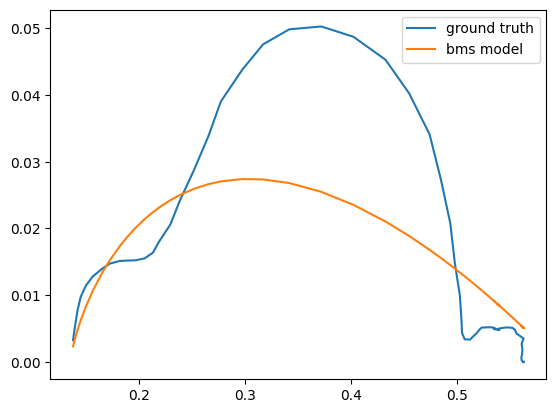

0.14151803812661945
(-9.999, 0.5)
optimized x0 [0.14321029] 0.137858
final fit


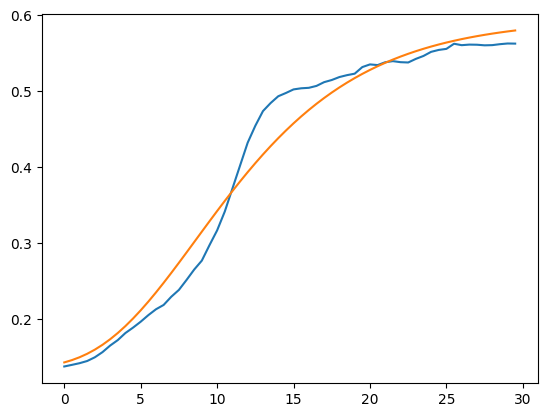

-0.3452622658271791 -0.08035224334604994 -0.22666905150181113
inverted parabola?


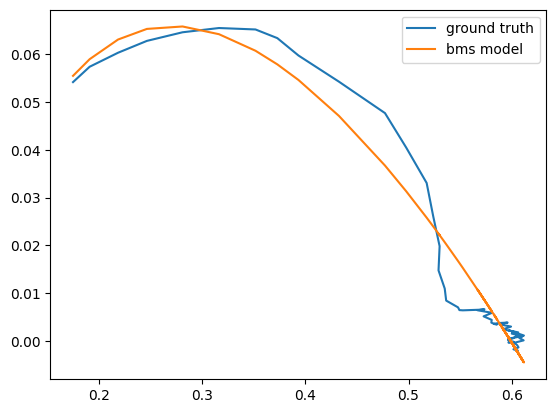

0.1634202802577539
(-9.999, 0.5)
optimized x0 [0.16342028] 0.1634202802577539
final fit


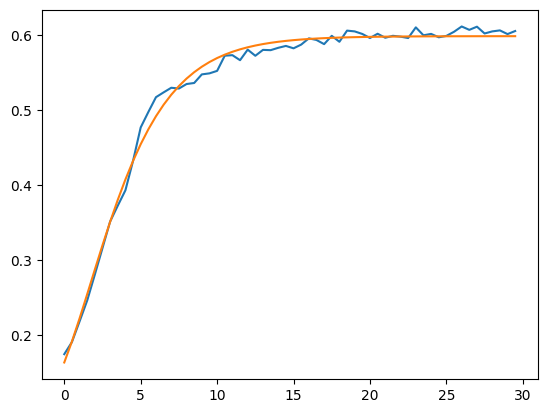

-0.5439822501181851 -0.4136913432376692 -0.671931101695899
inverted parabola?


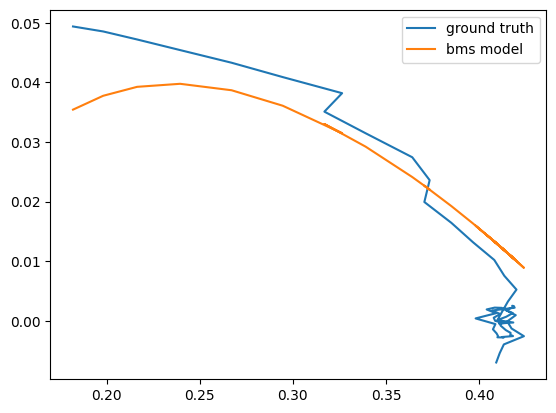

0.1097
(-9.999, 0.5)
optimized x0 [0.18618545] 0.181902
final fit


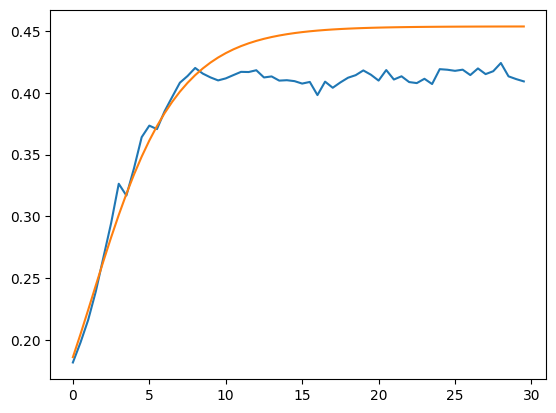

-0.16593449688485282 0.15299977811386378 0.015444214357514708
inverted parabola?


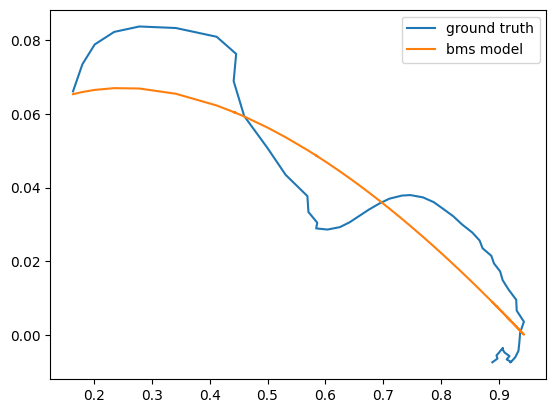

0.1610919618936869
(-9.999, 0.5)
optimized x0 [0.16109196] 0.1610919618936869
final fit


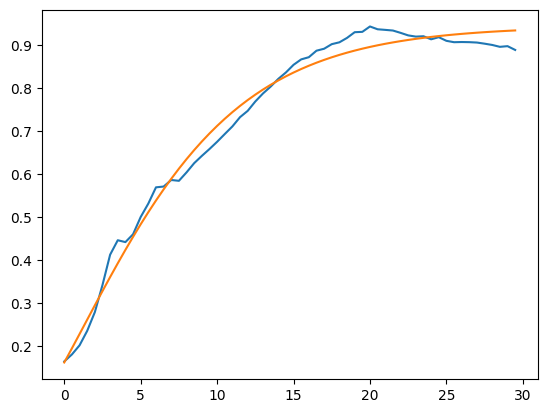

-0.2892660909072662 -0.19282732203325006 0.21694649119562767
inverted parabola?


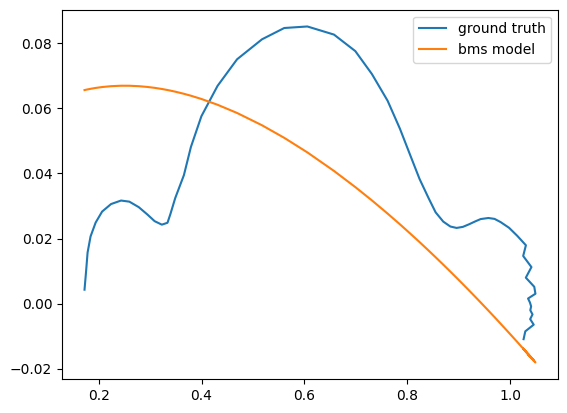

0.1610919618936869
(-9.999, 0.5)
optimized x0 [0.172566] 0.172566
final fit


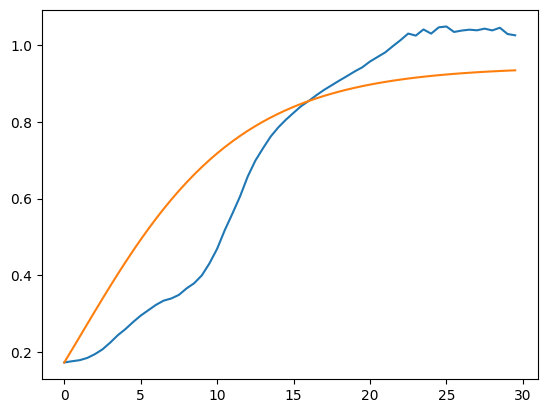

-0.7196392653391761 -0.4385595318497613 -0.5499173291162636
inverted parabola?


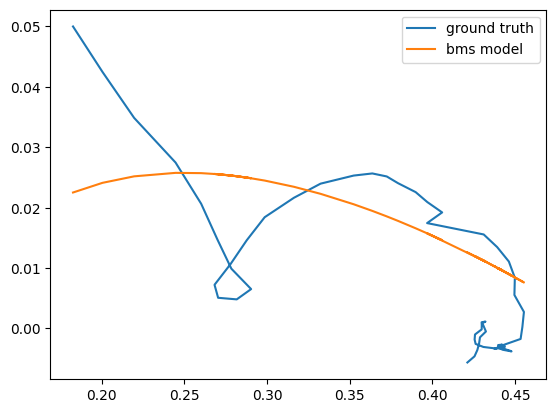

0.1154
(-9.999, 0.5)
optimized x0 [0.182704] 0.182704
final fit


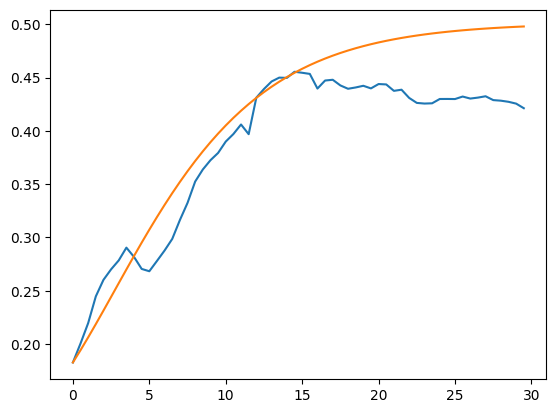

0.07623575087397912 -0.6823361451692073 -0.32349715493925807
inverted parabola?


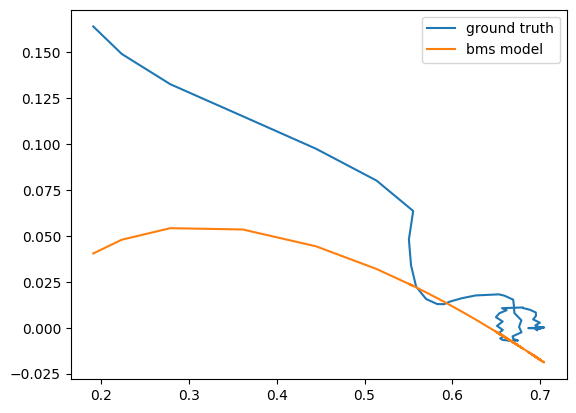

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.3217456] 0.19093
final fit


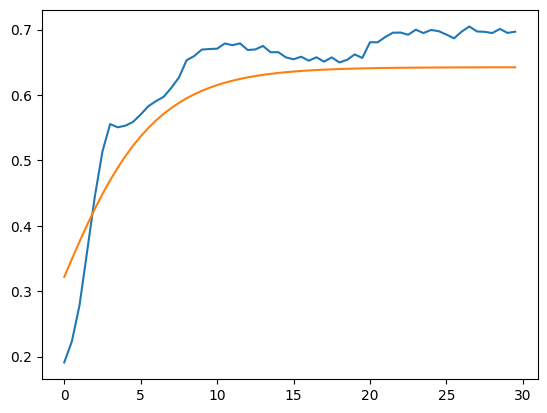

-0.25260623367241813 -0.6738677895999439 -0.3131716051388891
inverted parabola?


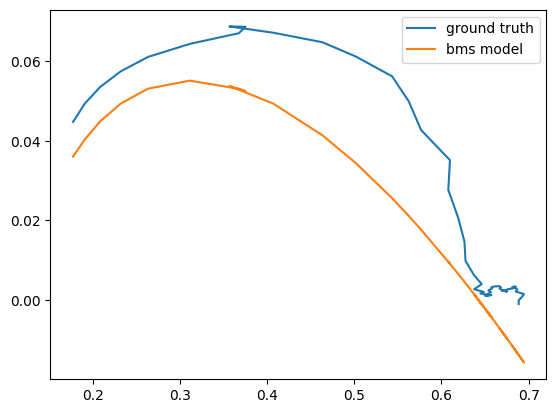

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.20328008] 0.177105
final fit


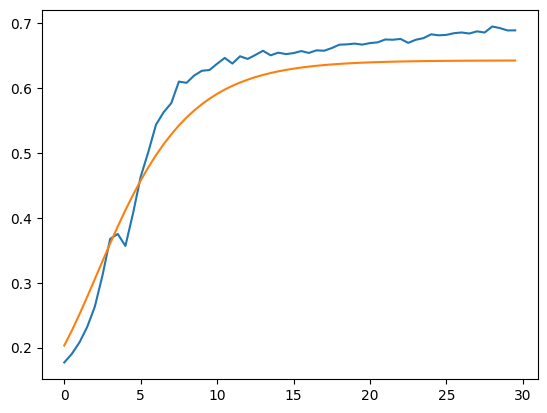

-0.3020681026969531 -0.15525530256289616 -0.2822944189533313
inverted parabola?


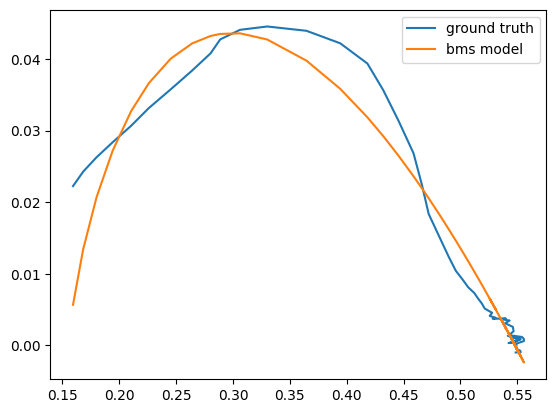

0.16409338039678725
(-9.999, 0.5)
optimized x0 [0.16409338] 0.16409338039678725
final fit


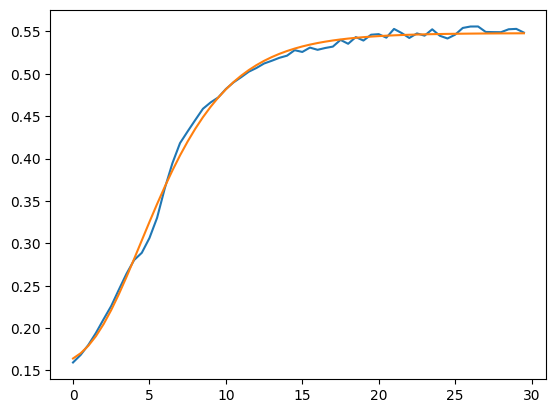

-0.3529132101276947 -0.016176686162297352 -0.1999370272767759
inverted parabola?


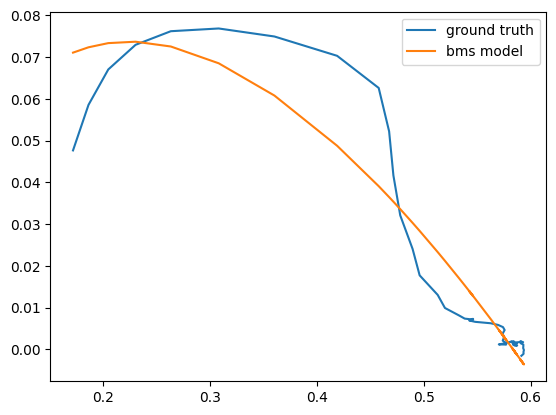

0.1481450709475015
(-9.999, 0.5)
optimized x0 [0.14814507] 0.1481450709475015
final fit


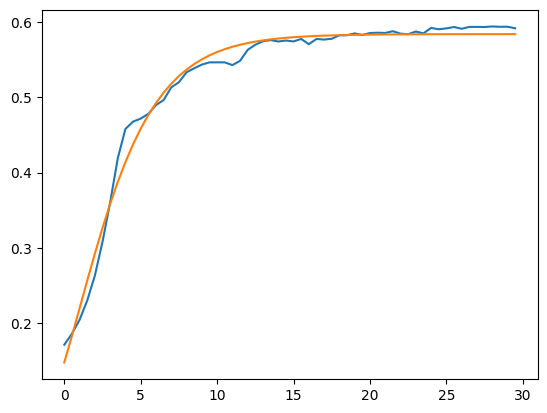

-0.22441166725706363 -0.6448303383943728 -0.40634299860229484
inverted parabola?


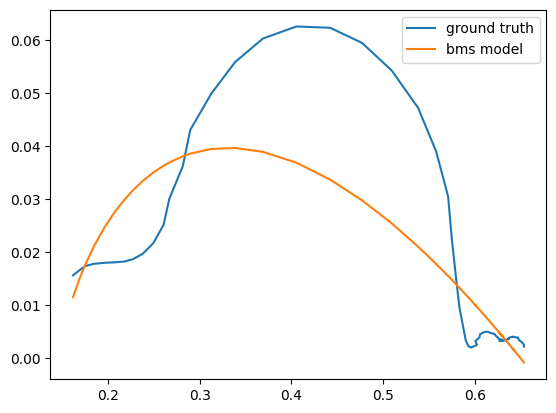

0.14670215287896843
(-9.999, 0.5)
optimized x0 [0.1617] 0.1617
final fit


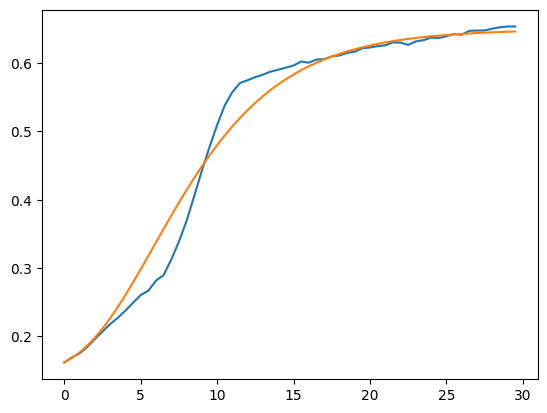

0.08601274868800911 -0.8777758143330175 0.006328540977615336
inverted parabola?


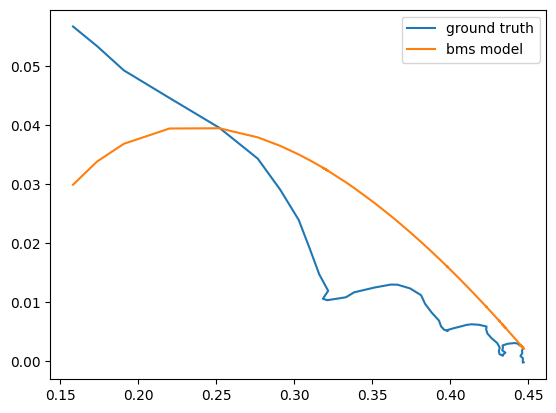

0.1097
(-9.999, 0.5)
optimized x0 [0.15827] 0.15827
final fit


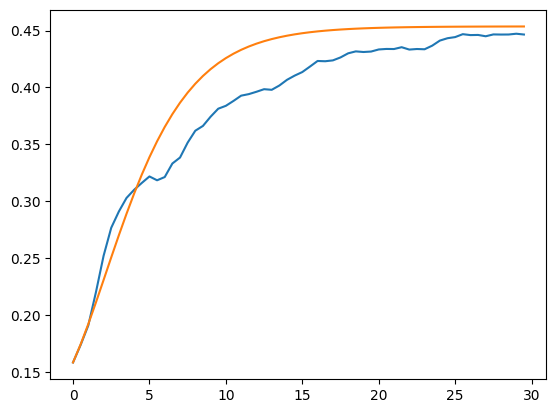

0.044078695534658215 -0.6615006850180939 -0.3370022882001058
inverted parabola?


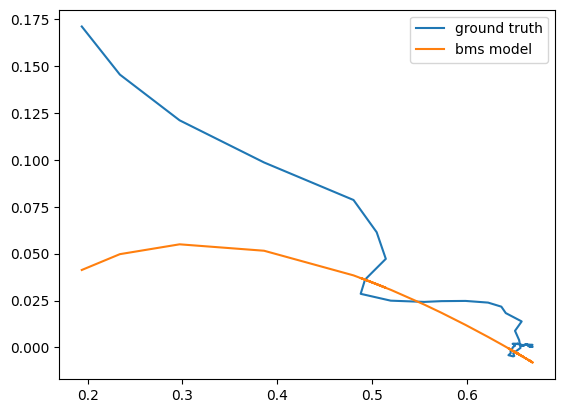

0.12515315928974796
(-9.999, 0.5)
optimized x0 [0.3141014] 0.193881
final fit


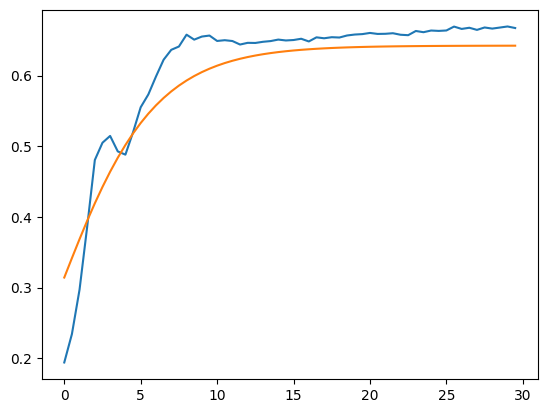

-0.4333821151790316 -0.4399858746400572 -0.5340925112584016
inverted parabola?


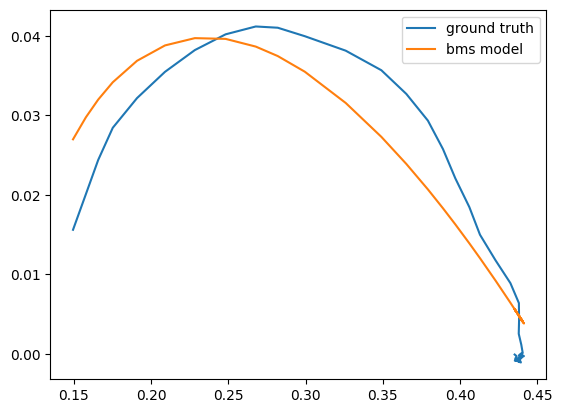

0.1097
(-9.999, 0.5)
optimized x0 [0.149507] 0.149507
final fit


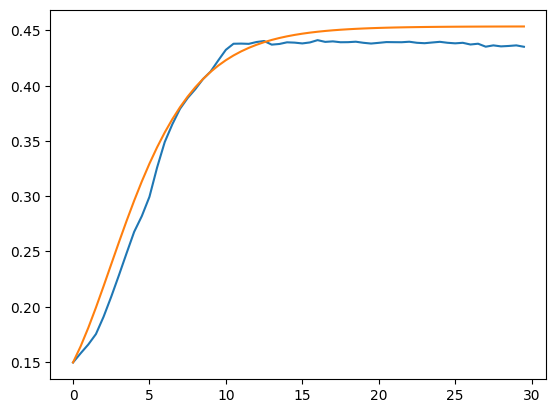

-0.22882155927419315 -0.5201846092531428 -0.26270399272346395
inverted parabola?


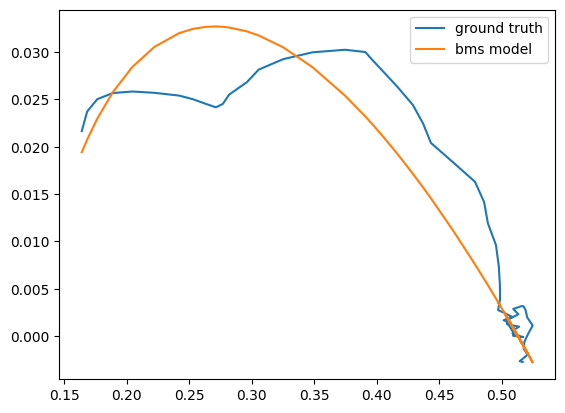

0.12946808171552507
(-9.999, 0.5)
optimized x0 [0.164184] 0.164184
final fit


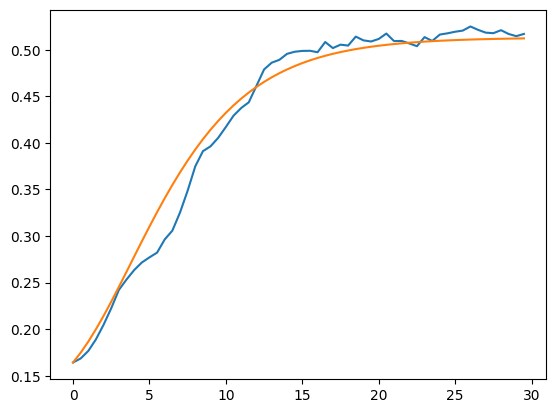

-0.8921416862524667 -0.11114375546477556 -0.7683783756603099
inverted parabola?


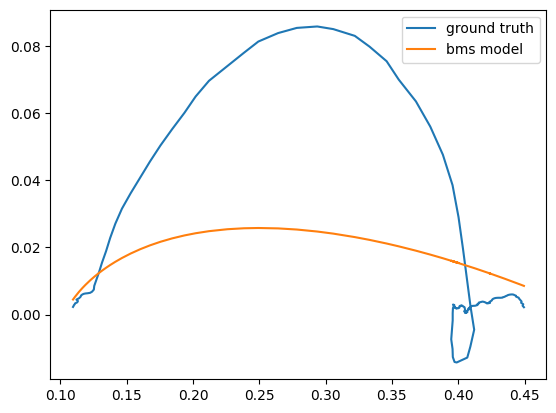

0.1154
(-9.999, 0.5)
optimized x0 [0.12474071] 0.1096
final fit


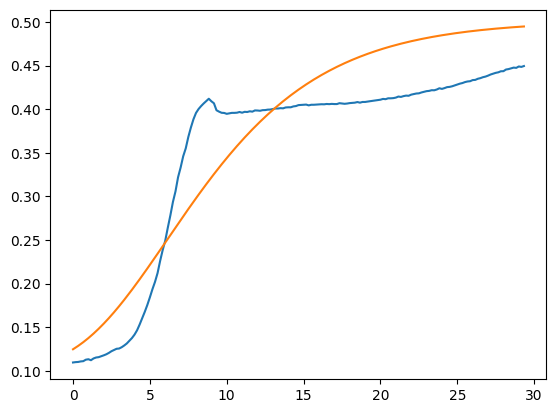

-0.18802800485481183 -0.4696346372103817 -0.40408049665303203
inverted parabola?


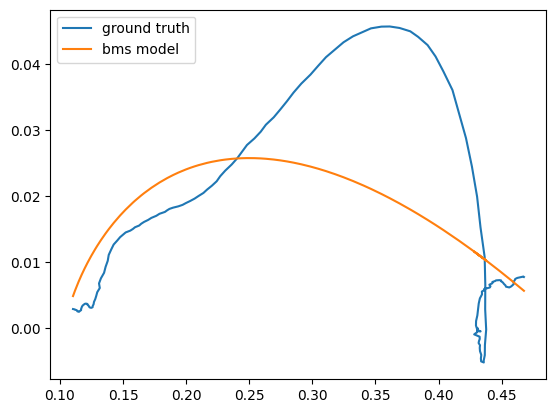

0.1154
(-9.999, 0.5)
optimized x0 [0.1104] 0.1104
final fit


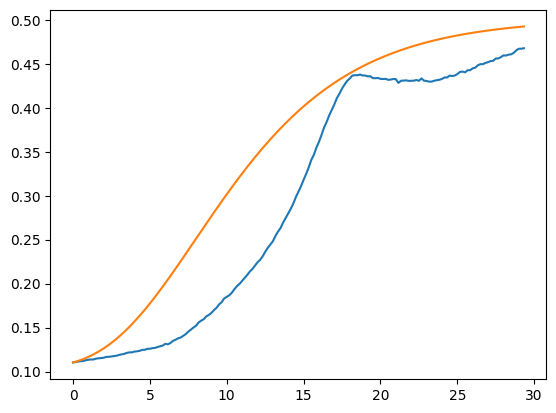

-0.4456685632820021 -0.4727343310630391 -0.9586808575613865
inverted parabola?


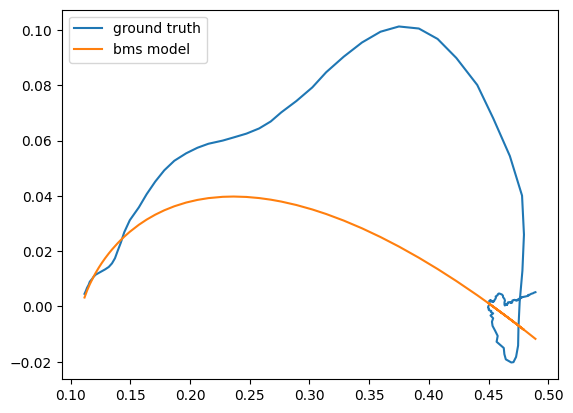

0.1097
(-9.999, 0.5)
optimized x0 [0.13623581] 0.1117
final fit


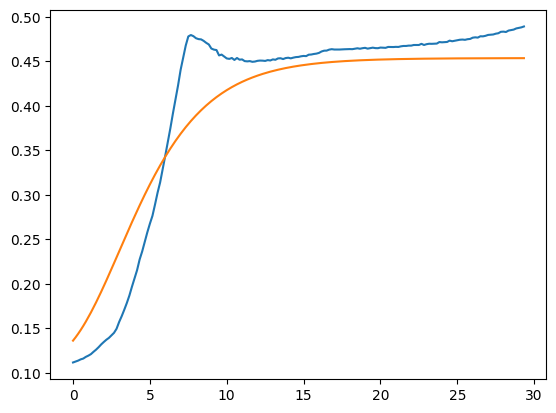

-0.15503301731927238 -0.113299998923959 -0.13493635785447625
inverted parabola?


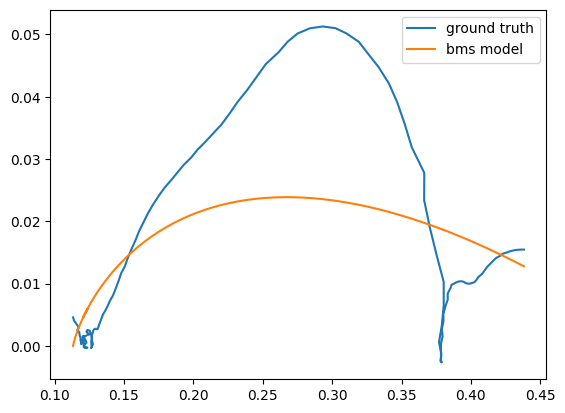

0.1133
(-9.999, 0.5)
optimized x0 [0.1133] 0.1133
final fit


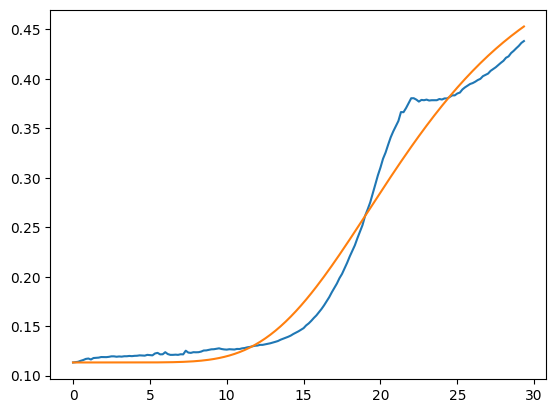

-0.16037850429368525 -0.11395604082805859 -0.08551509530434015
inverted parabola?


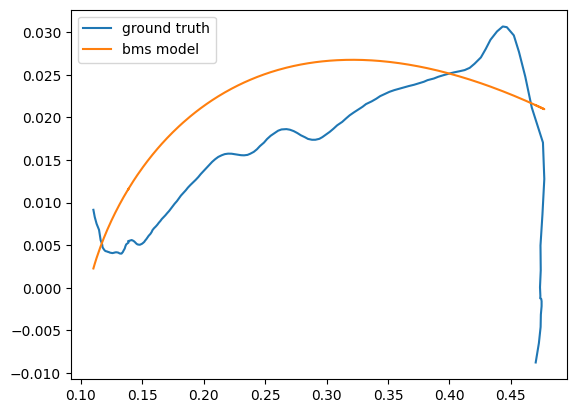

0.128531
(-9.999, 0.5)
optimized x0 [0.1103] 0.1103
final fit


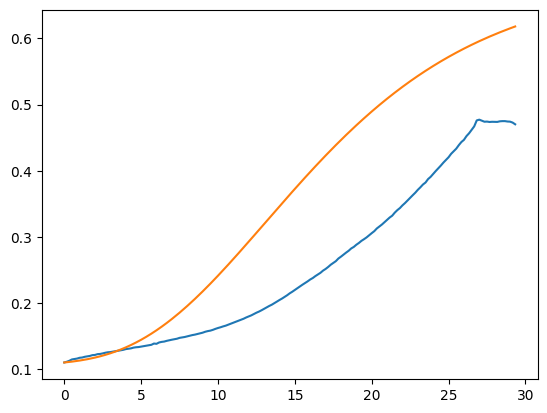

-0.17612371098069324 -0.10354012936404837 -0.16229886489703446
inverted parabola?


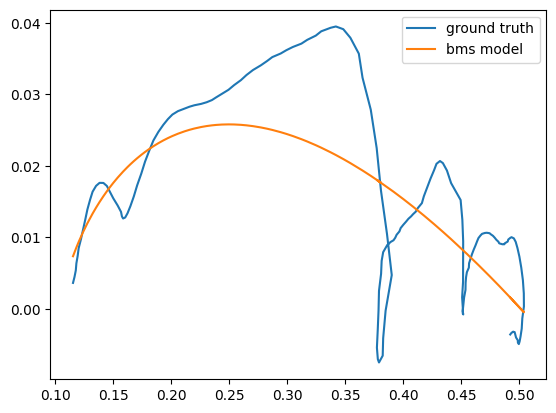

0.1154
(-9.999, 0.5)
optimized x0 [0.1154] 0.1154
final fit


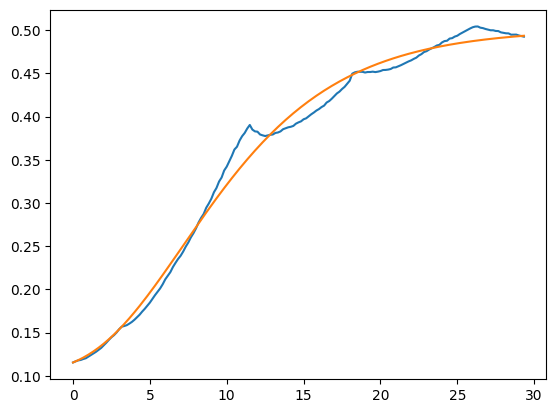

-1.5522440375733992 -0.13800069684591473 -0.3649395393189108
inverted parabola?


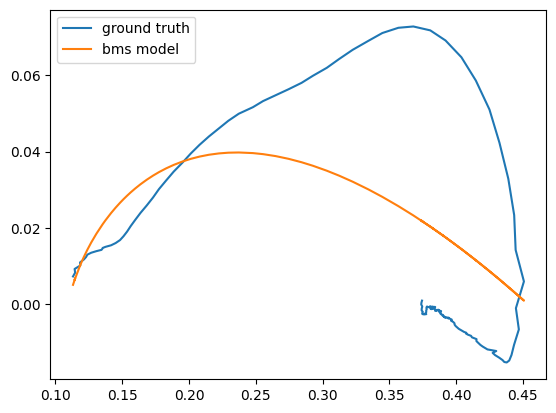

0.1097
(-9.999, 0.5)
optimized x0 [0.1132] 0.1132
final fit


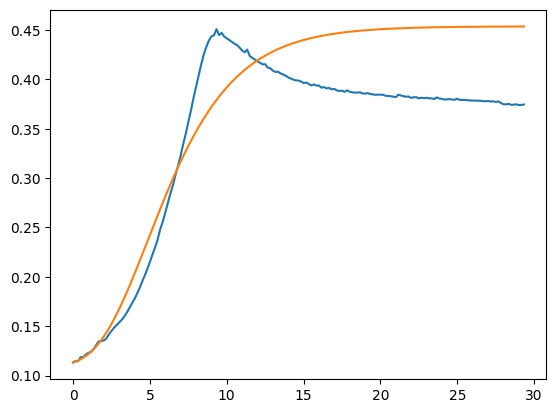

-0.17057688302913512 -0.11560077174743771 -0.06623278703092128
inverted parabola?


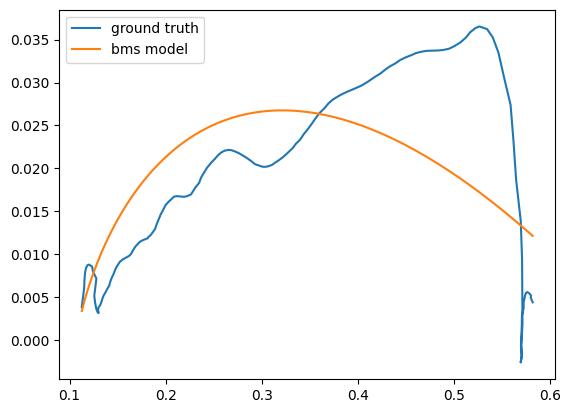

0.128531
(-9.999, 0.5)
optimized x0 [0.1127] 0.1127
final fit


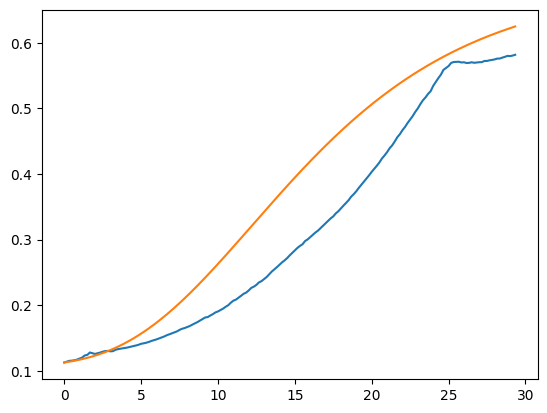

-0.3890498732887314 -0.11323782255227471 -0.4198867693058335
inverted parabola?


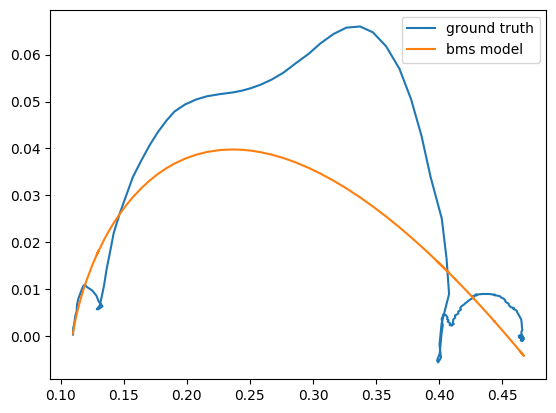

0.1097
(-9.999, 0.5)
optimized x0 [0.11324159] 0.11324158806756376
final fit


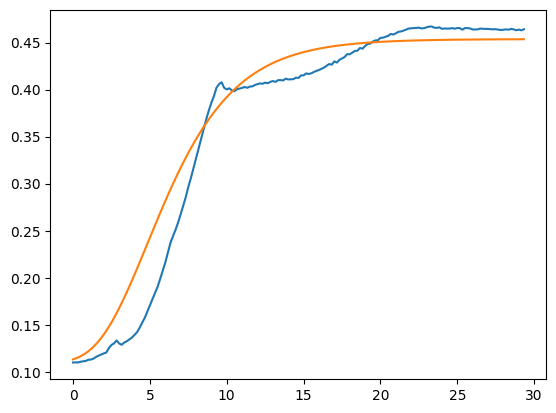

-0.3142756456962406 -0.10969999758042608 -0.3353767414320677
inverted parabola?


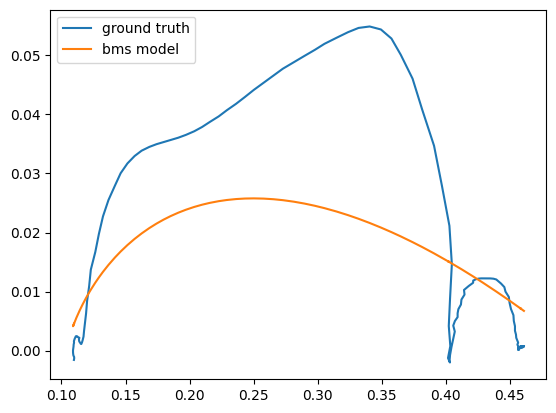

0.1154
(-9.999, 0.5)
optimized x0 [0.1097] 0.1097
final fit


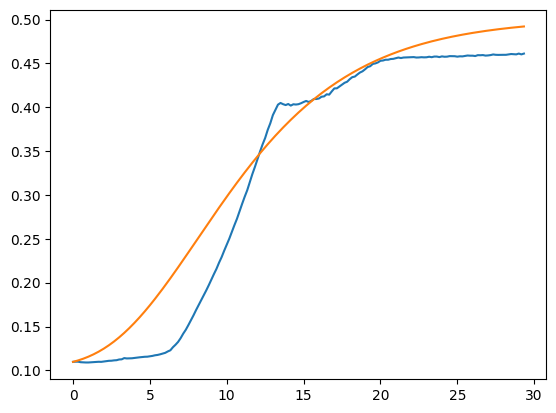

-0.22941507504512354 -0.503121210820275 -0.5013691899252432
inverted parabola?


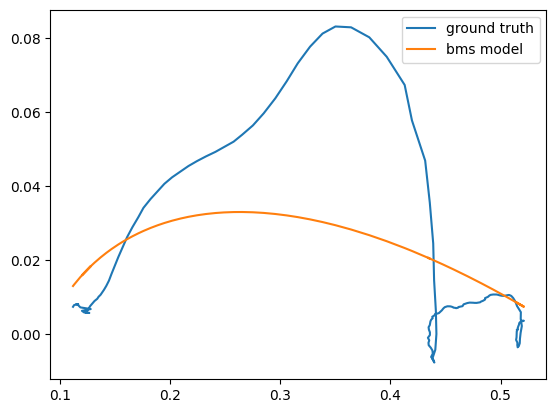

0.141528
(-9.999, 0.5)
optimized x0 [0.1121] 0.1121
final fit


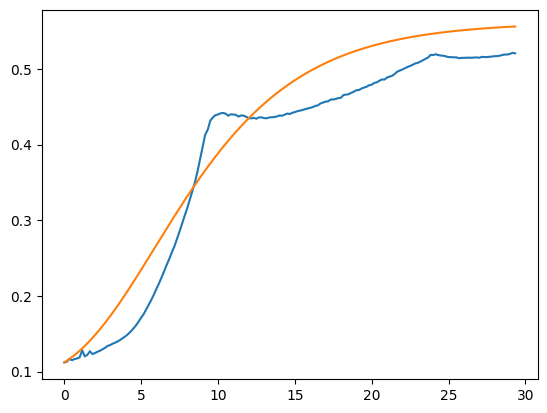

-0.07230740331745211 -0.65034593524955 -0.11337579278750559
inverted parabola?


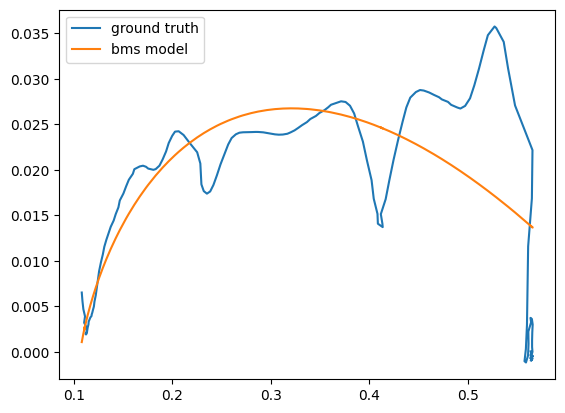

0.128531
(-9.999, 0.5)
optimized x0 [0.10884118] 0.1082
final fit


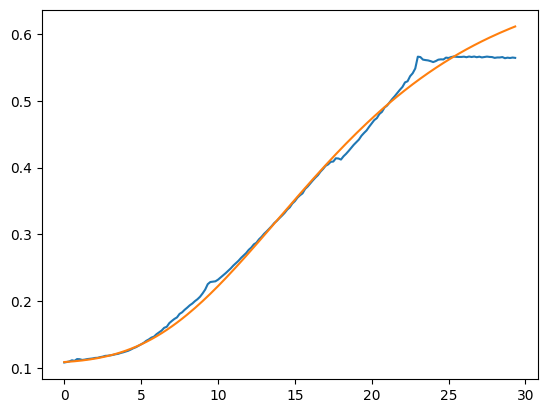

-0.23149746929824666 -0.1291347803229788 -0.22157434323355482
inverted parabola?


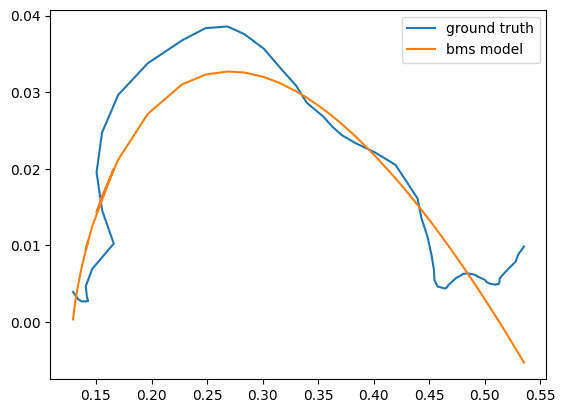

0.12946808171552507
(-9.999, 0.5)
optimized x0 [0.12946808] 0.12946808171552507
final fit


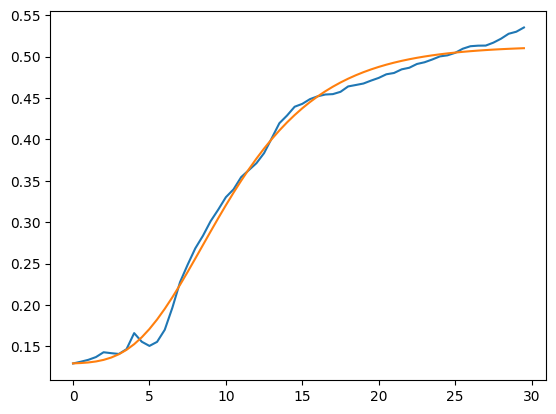

-0.12445449991285677 -0.1251127211068656 -0.07196604988357824
inverted parabola?


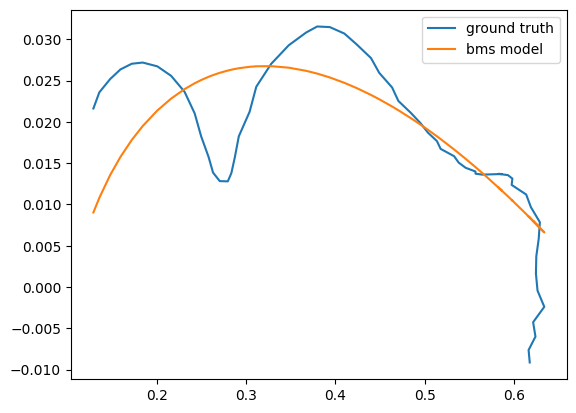

0.128531
(-9.999, 0.5)
optimized x0 [0.14886556] 0.14886556361643033
final fit


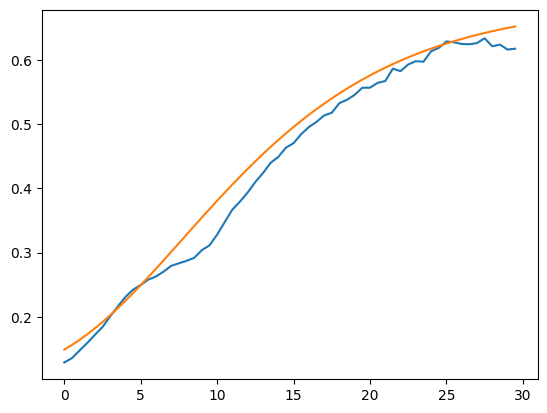

-0.17295143149988437 -0.4676922301180345 -0.2857385078573273
inverted parabola?


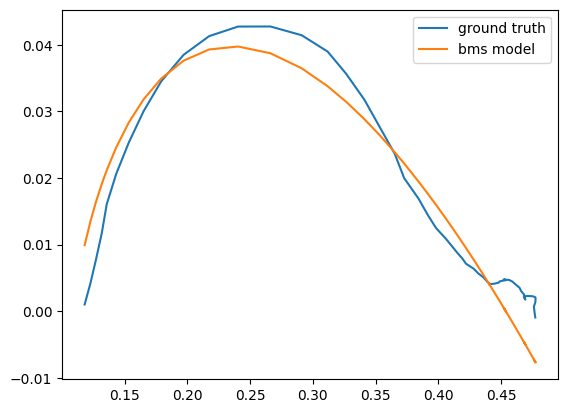

0.11324158806756376
(-9.999, 0.5)
optimized x0 [0.118245] 0.118245
final fit


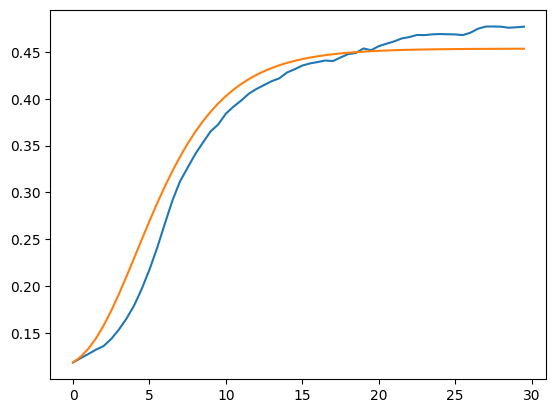

-0.10887572016711451 -0.12123385159190155 -0.06848413892988164
inverted parabola?


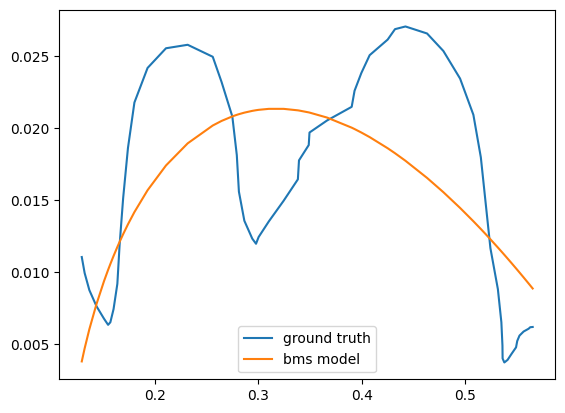

0.13308642891999523
(-9.999, 0.5)
optimized x0 [0.13308643] 0.13308642891999523
final fit


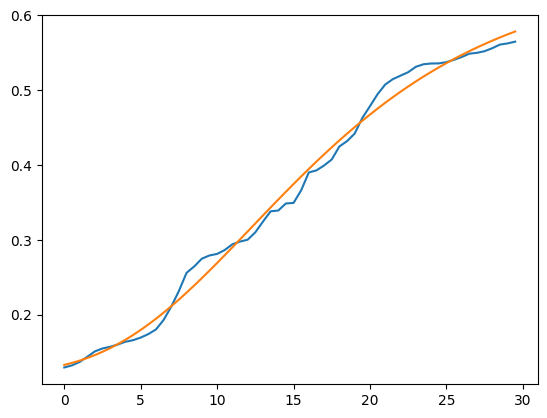

-0.1673598617499092 -0.6456180182903312 -0.2127517245929102
inverted parabola?


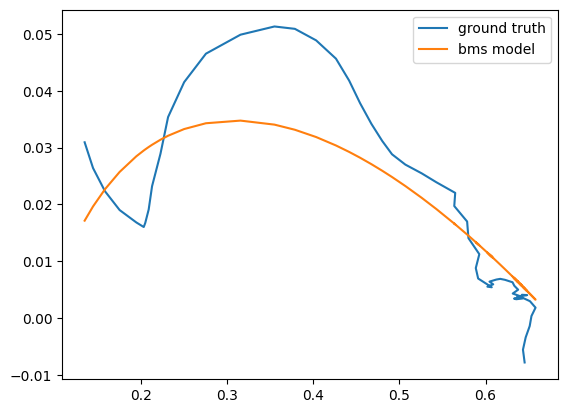

0.12657879516559173
(-9.999, 0.5)
optimized x0 [0.14121333] 0.134298
final fit


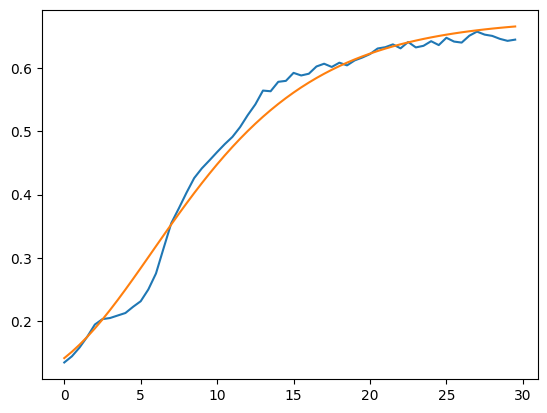

-0.21411149755380215 -0.14644287288350258 -0.14713101329331849
inverted parabola?


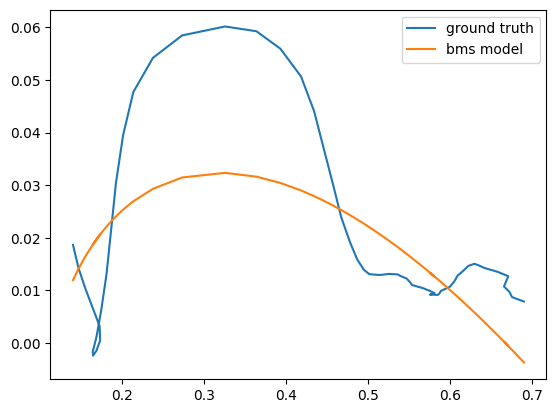

0.126466
(-9.999, 0.5)
optimized x0 [0.14670215] 0.14670215287896843
final fit


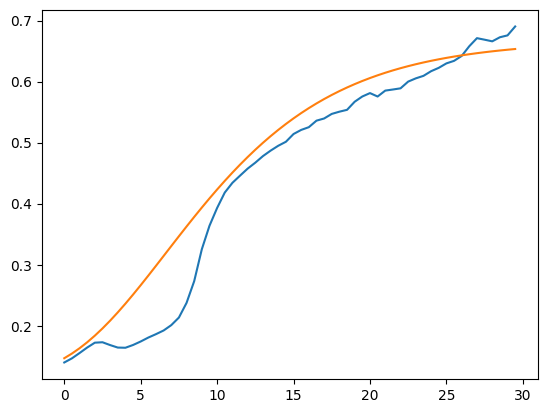

-0.11490407865694402 -0.07079836651941195 -0.028559559987666405
inverted parabola?


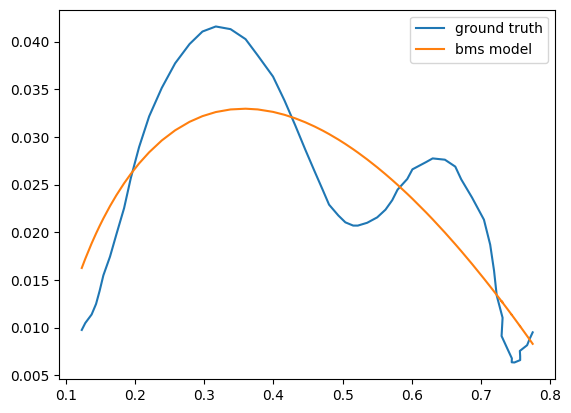

0.17572623471363114
(-9.999, 0.5)
optimized x0 [0.11297221] 0.11297221342708645
final fit


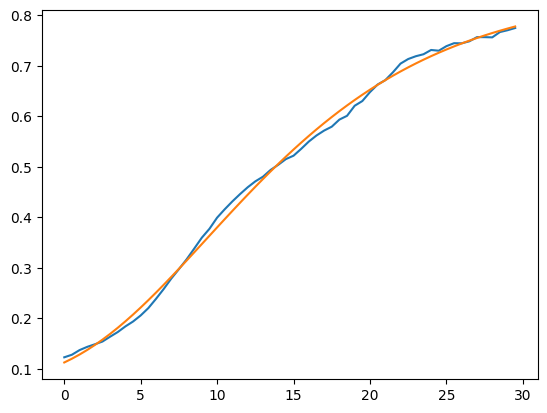

-0.12474650960374152 -0.1067506556270986 -0.06730057802544555
inverted parabola?


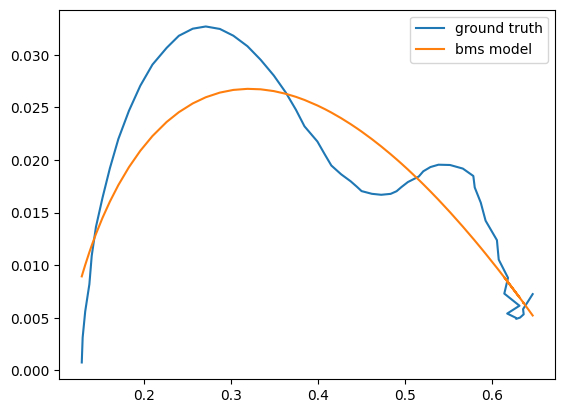

0.14886556361643033
(-9.999, 0.5)
optimized x0 [0.128531] 0.128531
final fit


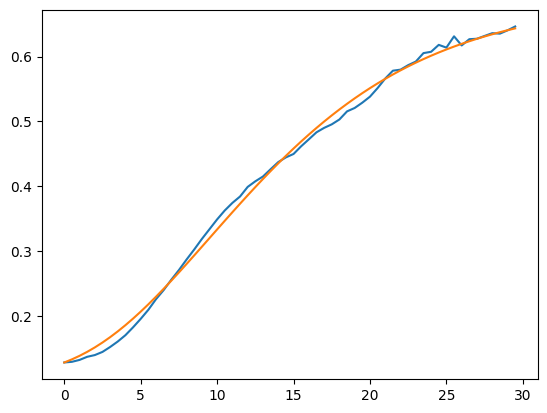

-0.1618808615386476 -0.09506094643118534 -0.08720338647698915
inverted parabola?


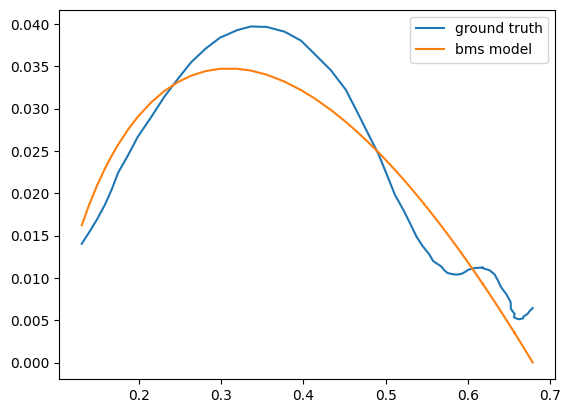

0.12657879516559173
(-9.999, 0.5)
optimized x0 [0.1265788] 0.12657879516559173
final fit


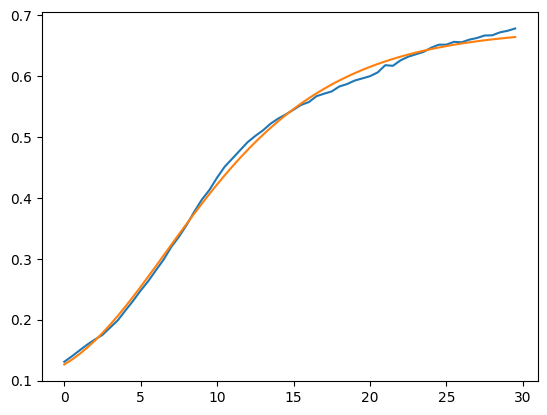

-0.3003177625081989 -0.13236722969673914 -0.009554339332093749
inverted parabola?


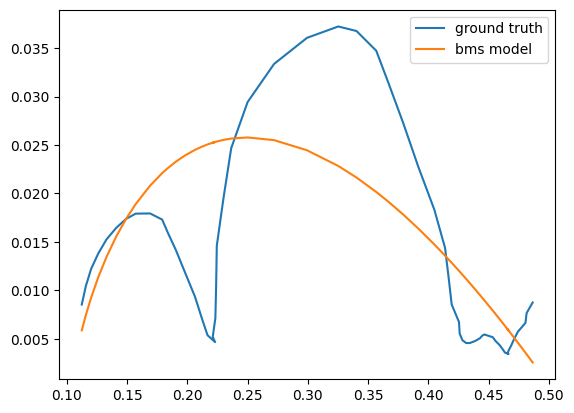

0.1154
(-9.999, 0.5)
optimized x0 [0.112274] 0.112274
final fit


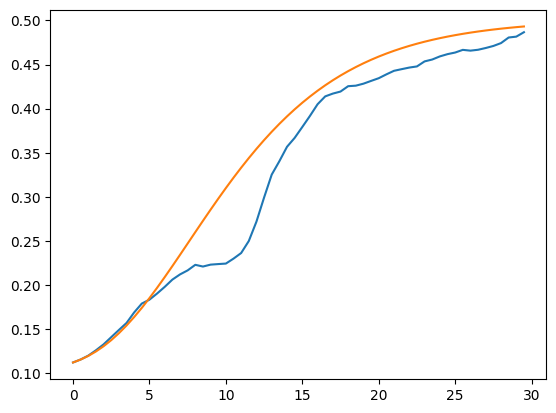

-0.161914912206917 -0.1349898885023361 -0.12557893896925248
inverted parabola?


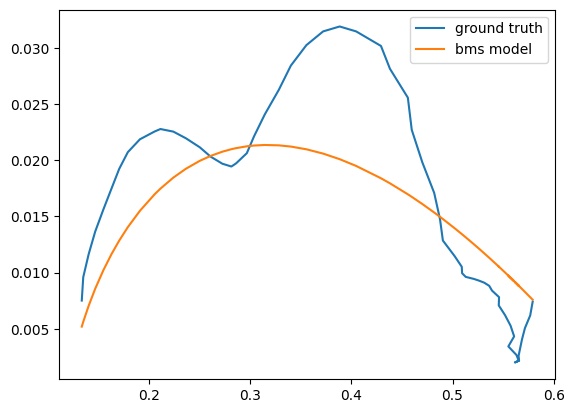

0.13308642891999523
(-9.999, 0.5)
optimized x0 [0.15448602] 0.14151803812661945
final fit


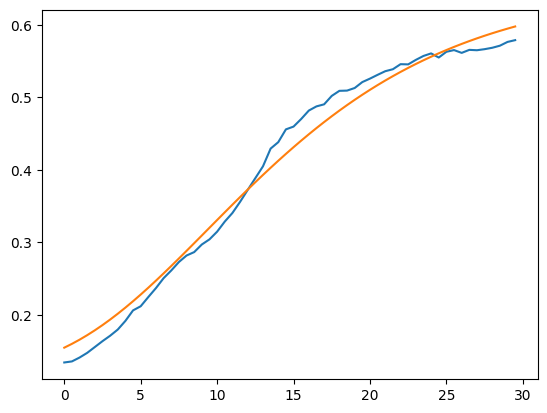

-0.15702507982769762 -0.5229076481554837 -0.24970812843761048
inverted parabola?


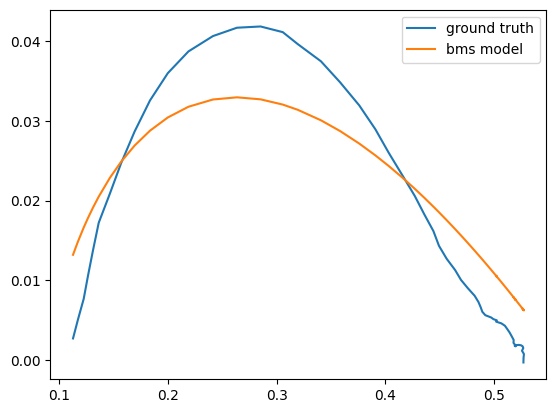

0.141528
(-9.999, 0.5)
optimized x0 [0.112879] 0.112879
final fit


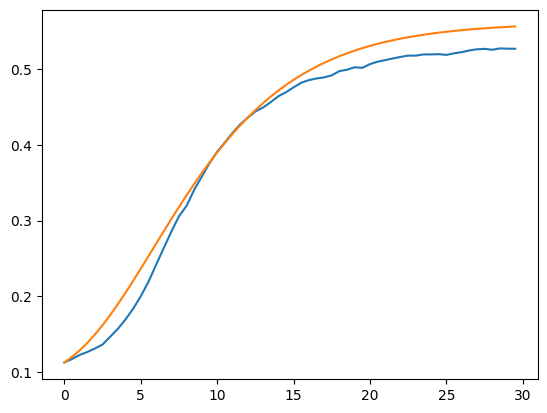

-0.1594837334230469 -0.11583451162888661 -0.09481911185914293
inverted parabola?


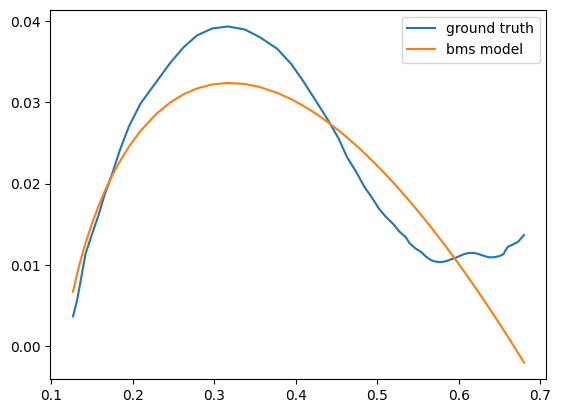

0.14670215287896843
(-9.999, 0.5)
optimized x0 [0.126466] 0.126466
final fit


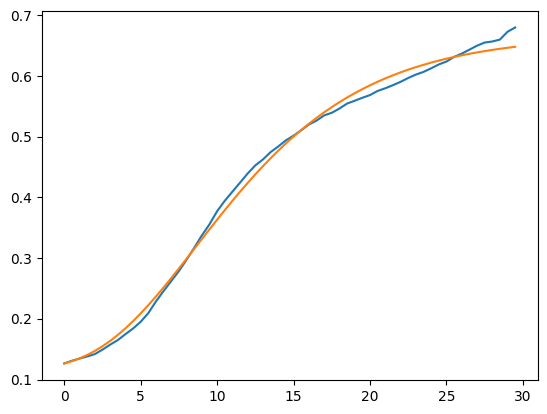

-0.6782931763414565 -0.1456863969643175 -0.15956025616335168
inverted parabola?


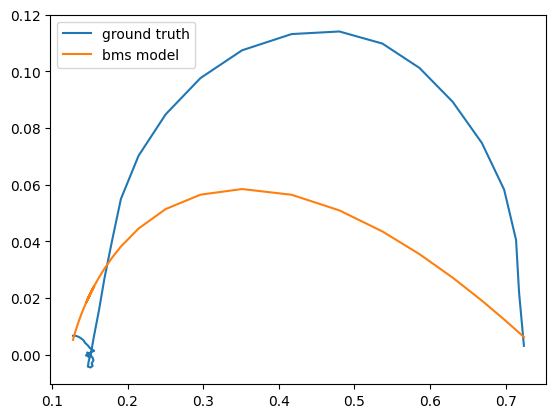

0.127212
(-9.999, 0.5)
optimized x0 [0.127915] 0.127915
final fit


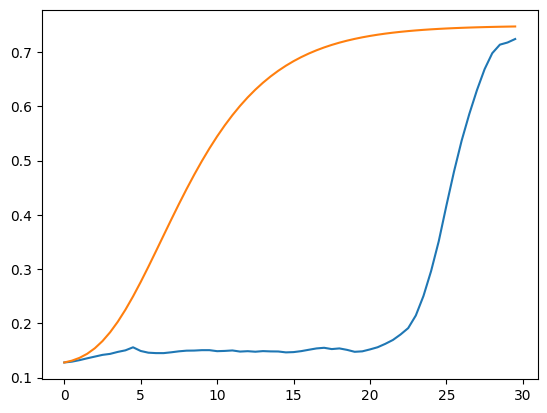

-0.15671268643037367 -0.7323323794455607 -0.2929120017774773
inverted parabola?


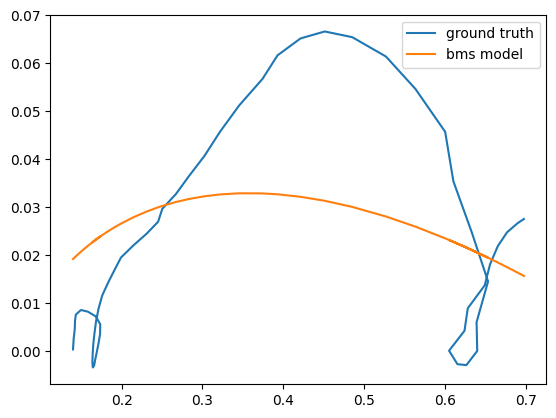

0.17572623471363114
(-9.999, 0.5)
optimized x0 [0.139895] 0.139895
final fit


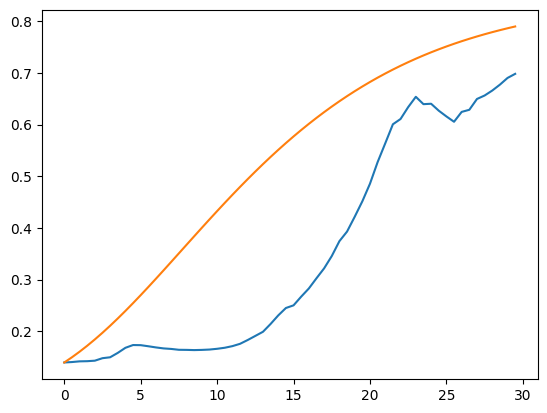

-0.1389539358501782 -0.871560653763755 -0.2637235010300018
inverted parabola?


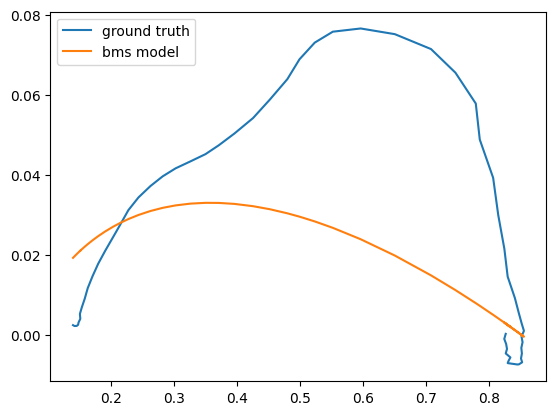

0.17572623471363114
(-9.999, 0.5)
optimized x0 [0.139658] 0.139658
final fit


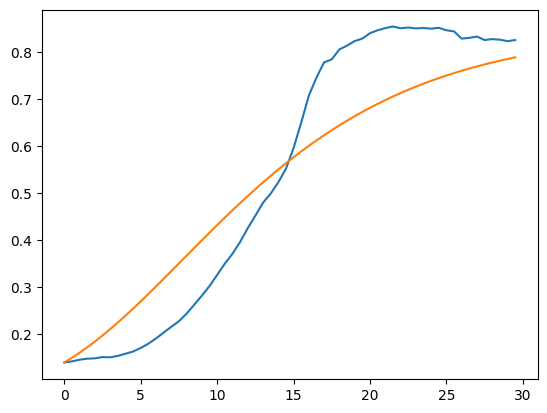

-0.09309495550074211 -0.6370740592982608 -0.11594451210820958
inverted parabola?


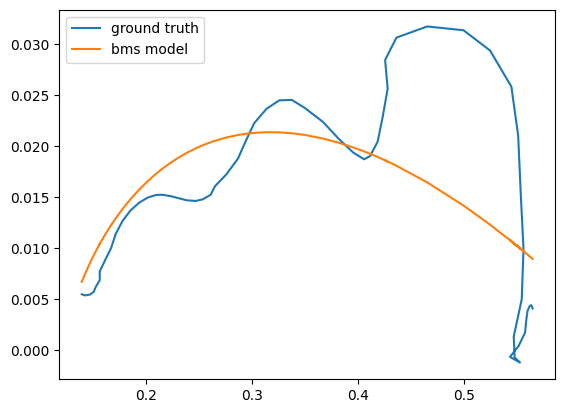

0.13308642891999523
(-9.999, 0.5)
optimized x0 [0.139368] 0.139368
final fit


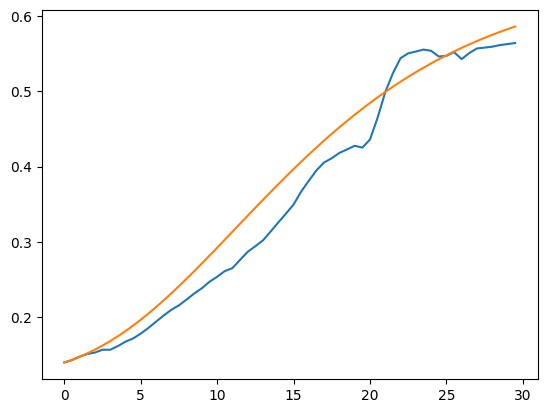

-0.42000544234985787 -0.16584076707886494 0.2288183707048382
inverted parabola?


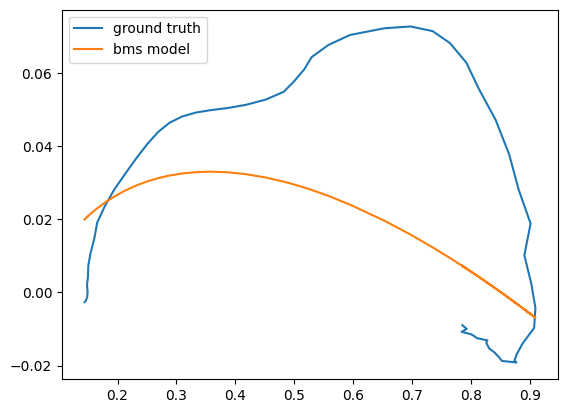

0.17572623471363114
(-9.999, 0.5)
optimized x0 [0.15612257] 0.144024
final fit


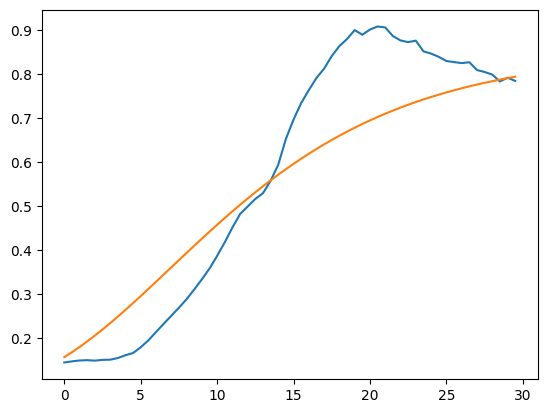

-0.12703270168328223 -0.8311138960571929 -0.2511557685295984
inverted parabola?


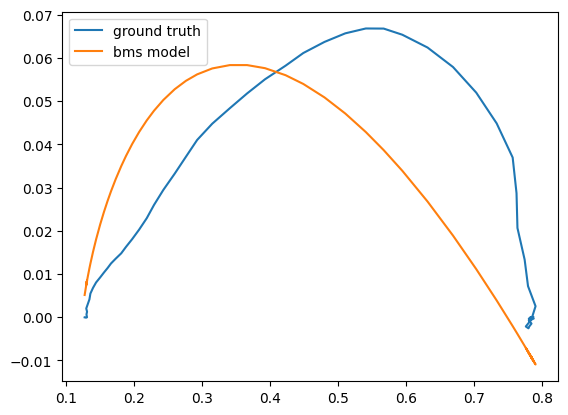

0.127212
(-9.999, 0.5)
optimized x0 [0.12786] 0.12786
final fit


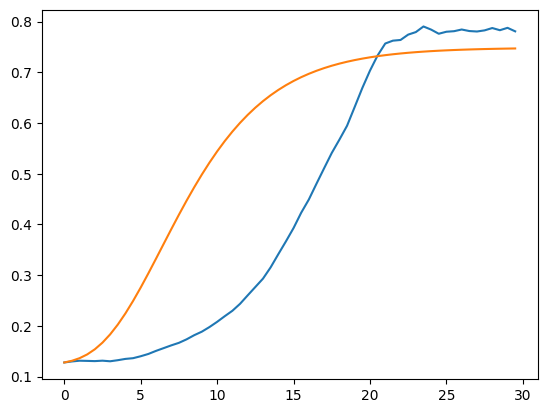

-0.3246734825896967 -0.5752897898691872 -0.34616088210187984
inverted parabola?


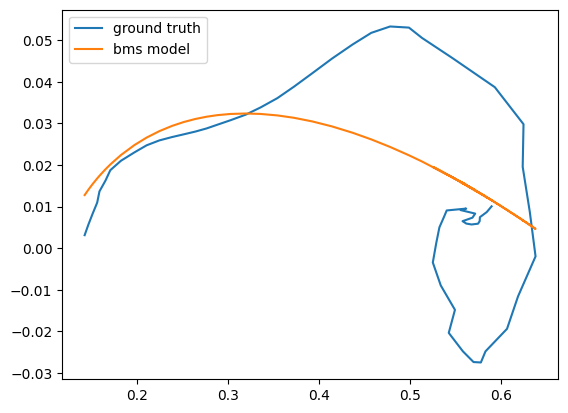

0.14670215287896843
(-9.999, 0.5)
optimized x0 [0.142137] 0.142137
final fit


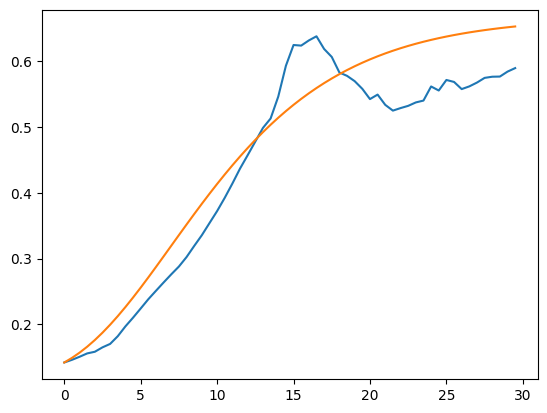

((_a0_ * (B + _a2_)) + (_a1_ * ((B + _a2_) * log((B + _a2_)))))
-10034.5155922631


In [3]:
bms_fulldata_new = deepcopy(bms_fulldata)
print(bms_fulldata_new.E)

for col in list(x.keys()):
    """
    h=x[col].t[1]-x[col].t[0]
    print('initial BMS fit')
    int0 = RK_BMS(bms_fulldata_new,bms_fulldata_new.x0[str(bms_fulldata_new)][col],h,len(y[col]),col)
    plt.plot(x[col].t.to_numpy(),x[col].B.to_numpy())
    plt.plot(x[col].t.to_numpy(),int0)
    plt.show()
    """
    print(bms_fulldata_new.par_values[col]['_a1_'], bms_fulldata_new.par_values[col]['_a2_'], bms_fulldata_new.par_values[col]['_a0_'])
    if np.isinf(bms_fulldata_new.sse[col]) or bms_fulldata_new.par_values[col]['_a1_']<0.:
        
        #fit = scipy.optimize.minimize(loss_ode,[1.,1.,1.],bounds=((0.,2.),(0.,2.),(None,None))).x
        
        #if bms_fulldata_new.par_values[col]['_a1_']<0.:

        # Check for the parameters that fit better to the derivative
        best_error = np.inf
        first_col=list(x.keys())[0]
        for col1 in list(x.keys()):
            if not np.isinf(bms_fulldata_new.sse[col1]):
                new_err = loss_ode([bms_fulldata_new.par_values[col1]['_a0_'],
                                                bms_fulldata_new.par_values[col1]['_a1_'],
                                                bms_fulldata_new.par_values[col1]['_a2_']])
                
                if new_err<best_error:
                    best_error = deepcopy(new_err)
                    first_col=deepcopy(col1)

        
        bms_fulldata_new.par_values[col] = deepcopy(bms_fulldata_new.par_values[first_col])
        
        print('inverted parabola?')
        plt.plot(x[col].B.to_numpy(),x[col].dx.to_numpy(),label='ground truth')
        plt.plot(x[col].B.to_numpy(),ode0(x[col].B.to_numpy(),x[col].t.to_numpy(),
                                          bms_fulldata_new.par_values[col]['_a0_'],
                                            bms_fulldata_new.par_values[col]['_a1_'],
                                            bms_fulldata_new.par_values[col]['_a2_']),
                                          label='bms model')
        
        #plt.plot(x[col].B.to_numpy(),ode0(x[col].B.to_numpy(),x[col].t.to_numpy(),*fit),
        #                                  label='new fit model')
        plt.legend()
        plt.show()
        
        
        print(bms_fulldata_new.x0[str(bms_fulldata_new)][first_col])
        def func(x):
            return ode0(x,1.,bms_fulldata_new.par_values[col]['_a0_'],
                                            bms_fulldata_new.par_values[col]['_a1_'],
                                            bms_fulldata_new.par_values[col]['_a2_'])
        deriv_root=scipy.optimize.root_scalar(func, bracket=[-10., max(x[col].B.to_numpy())*0.5]).root
        print((deriv_root+1e-3,0.5))
        if deriv_root>0.5:
            deriv_root=1e-4
        new_x0 = scipy.optimize.minimize(fit_initial_value,bms_fulldata_new.x0[str(bms_fulldata_new)][col],bounds=[(deriv_root+1e-4,0.5)]).x
        print('optimized x0',new_x0,bms_fulldata_new.x0[str(bms_fulldata_new)][col])
        bms_fulldata_new.x0[str(bms_fulldata_new)][col]=deepcopy(new_x0[0])
        
        #print(fit)
        """
        bms_fulldata_new.par_values[col]['_a1_'] = deepcopy(fit[0])
        bms_fulldata_new.par_values[col]['_a2_'] = deepcopy(fit[1])
        bms_fulldata_new.par_values[col]['_a0_'] = deepcopy(fit[2])
        bms_fulldata_new.x0[str(bms_fulldata_new)][col]=deepcopy(x[col].B.to_numpy()[0])
        
        bms_fulldata_new.get_bic(reset=True,fit=False,verbose=True)
        """
        """
        if np.isinf(bms_fulldata_new.sse[col]):
            success=False
            init_points=np.linspace(x[col].B.to_numpy()[0],1.,1000)
            for i in init_points:
                bms_fulldata_new.x0[str(bms_fulldata_new)][col]=deepcopy(i)
                bms_fulldata_new.get_bic(reset=True,fit=False,verbose=True)
                print(i,bms_fulldata_new.sse[col])
                h=x[col].t[1]-x[col].t[0]
                int0 = RK_BMS(bms_fulldata_new,i,h,len(y[col]),col)
                if not np.isinf(bms_fulldata_new.sse[col]) and not np.isnan(sum(int0)) and not np.isinf(sum(int0)):
                    print('break!',bms_fulldata_new.sse[col],sum(int0))
                    success=True
                    break
            if success==None:
                print('sse not successful',bms_fulldata_new.sse[col])
                plt.plot(x[col].B.to_numpy(),x[col].dx.to_numpy(),label='ground truth')
                plt.plot(x[col].B.to_numpy(),ode0(x[col].B.to_numpy(),x[col].t.to_numpy(),*fit),label='model')
                plt.show()
        """
    
    h=x[col].t[1]-x[col].t[0]
    print('final fit')
    int0 = RK_BMS(bms_fulldata_new,bms_fulldata_new.x0[str(bms_fulldata_new)][col],h,len(y[col]),col)
    plt.plot(x[col].t.to_numpy(),x[col].B.to_numpy())
    plt.plot(x[col].t.to_numpy(),int0)
    plt.show()
    
bms_fulldata_new.get_bic(reset=True,fit=False,verbose=True)
bms_fulldata_new.get_energy(reset=True)
print(bms_fulldata_new.E)


In [4]:
bms_fulldata_new.fit_par={}
bms_fulldata_new.get_bic(reset=True,fit=True,verbose=True)
bms_fulldata_new.get_energy(reset=True)

print(bms_fulldata_new)
print(bms_fulldata_new.E)
print(bms_fulldata_new.sse)



f_name=f'{folder_name}/gompertz_train_fit_t.pkl'
file = open(f_name,'wb')
pickle.dump(bms_fulldata_new,file)
file.close()

((_a0_ * (B + _a2_)) + (_a1_ * ((B + _a2_) * log((B + _a2_)))))
Fit from fit 0.01106431227783731 -4.454707694317994e-05
Fit from par 0.011064313078983262 -9.844476615256115e-06
Fit from fit 0.002123151878014377 -3.1394902649806156e-09
Fit from par 0.0021231518779757643 -1.9062340178566117e-09
Fit from fit 0.018504970670170956 -1.7339186440534782e-06
Fit from par 0.018504970666021026 -1.458383041275102e-06
Fit from fit 0.005293264106283164 -9.377493281892413e-09
Fit from par 0.0052932641067315106 -4.943685627534222e-09
Fit from fit 0.027363992994579242 -1.7161249060704264e-08
Fit from par 0.027363993020194502 -7.167026996879322e-08
Fit from fit 0.014488992657195077 2.858543769329591e-07
Fit from par 0.014488992647531167 1.9704303581835614e-07
Fit from fit 0.026400205846675344 -4.9545578584275773e-08
Fit from par 0.026400205854359326 -6.29051941924974e-08
Fit from fit 0.05853354842261931 -0.1833376995312353
Fit from par 0.05814642186542418 -0.16839162282411804
Fit from fit 0.023757204250